### Step 1: Imports and Configuration
This step imports all necessary libraries for the project. These include packages for data manipulation (`numpy`, `pandas`), visualization (`matplotlib`, `seaborn`), standard machine learning models and utilities from `scikit-learn`, the gradient boosting library `xgboost`, the time-series forecasting library `prophet`, and deep learning modules from `tensorflow.keras`. Random seeds are also initialized to guarantee reproducibility across runs.


In [ ]:
# Cell 1: Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import random
random.seed(42)

# TensorFlow seed
import tensorflow as tf
tf.random.set_seed(42)

# Scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# XGBoost
import xgboost as xgb

# Prophet (using the correct import)
from prophet import Prophet

# TensorFlow/Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Clustering (for demonstration only)
from sklearn.cluster import KMeans

print("✅ All imports successful!")
print(f"TensorFlow version: {tf.__version__}")
print(f"XGBoost version: {xgb.__version__}")


✅ All imports successful!
TensorFlow version: 2.20.0
XGBoost version: 3.2.0


### Step 2: Download Bitcoin Data (2020–2026)
Here we download daily historical price data for Bitcoin (`BTC-USD`) using the Yahoo Finance API (`yfinance`) from January 1, 2020, to June 15, 2026. The dataset is filtered to retain only the closing prices, which are renamed to `close` for convenience, and basic data integrity checks (missing values, row counts, and date range) are performed.


In [ ]:
# Cell 2: Download Bitcoin data (2020-2026)
ticker = "BTC-USD"
start_date = "2020-01-01"
end_date = "2026-06-15"  # Current date as of this run

print(f"Downloading {ticker} data from {start_date} to {end_date}...")

df = yf.download(ticker, start=start_date, end=end_date, progress=True)

# Handle MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep only Close price for now
df = df[['Close']].copy()
df.columns = ['close']

print(f"\n✅ Data downloaded successfully!")
print(f"Total rows: {len(df)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())


[*********************100%***********************]  1 of 1 completed


✅ Data downloaded successfully!
Total rows: 2357
Date range: 2020-01-01 to 2026-06-14
Missing values: 0

First 5 rows:
                  close
Date                   
2020-01-01  7200.174316
2020-01-02  6985.470215
2020-01-03  7344.884277
2020-01-04  7410.656738
2020-01-05  7411.317383

Last 5 rows:
                   close
Date                    
2026-06-10  61449.289062
2026-06-11  63561.054688
2026-06-12  63543.199219
2026-06-13  64421.324219
2026-06-14  65710.398438


### Step 3: Exploratory Data Analysis (EDA) — Price Overview
This step visualizes the historical closing price of Bitcoin, daily log returns, and 30-day rolling annualized volatility. Key statistical properties (mean daily return, skewness, kurtosis, and return volatility) are computed to understand the distribution, tails, and overall volatility profile of Bitcoin prices.


📊 EXPLORATORY DATA ANALYSIS

Dataset shape: (2357, 1)
Date range: 2020-01-01 → 2026-06-14
Total trading days: 2357

Close Price Statistics:
count      2357.00
mean      49155.76
std       31220.85
min        4970.79
25%       23198.13
50%       42623.54
75%       68402.38
max      124752.53
Name: close, dtype: float64

Missing values: 0


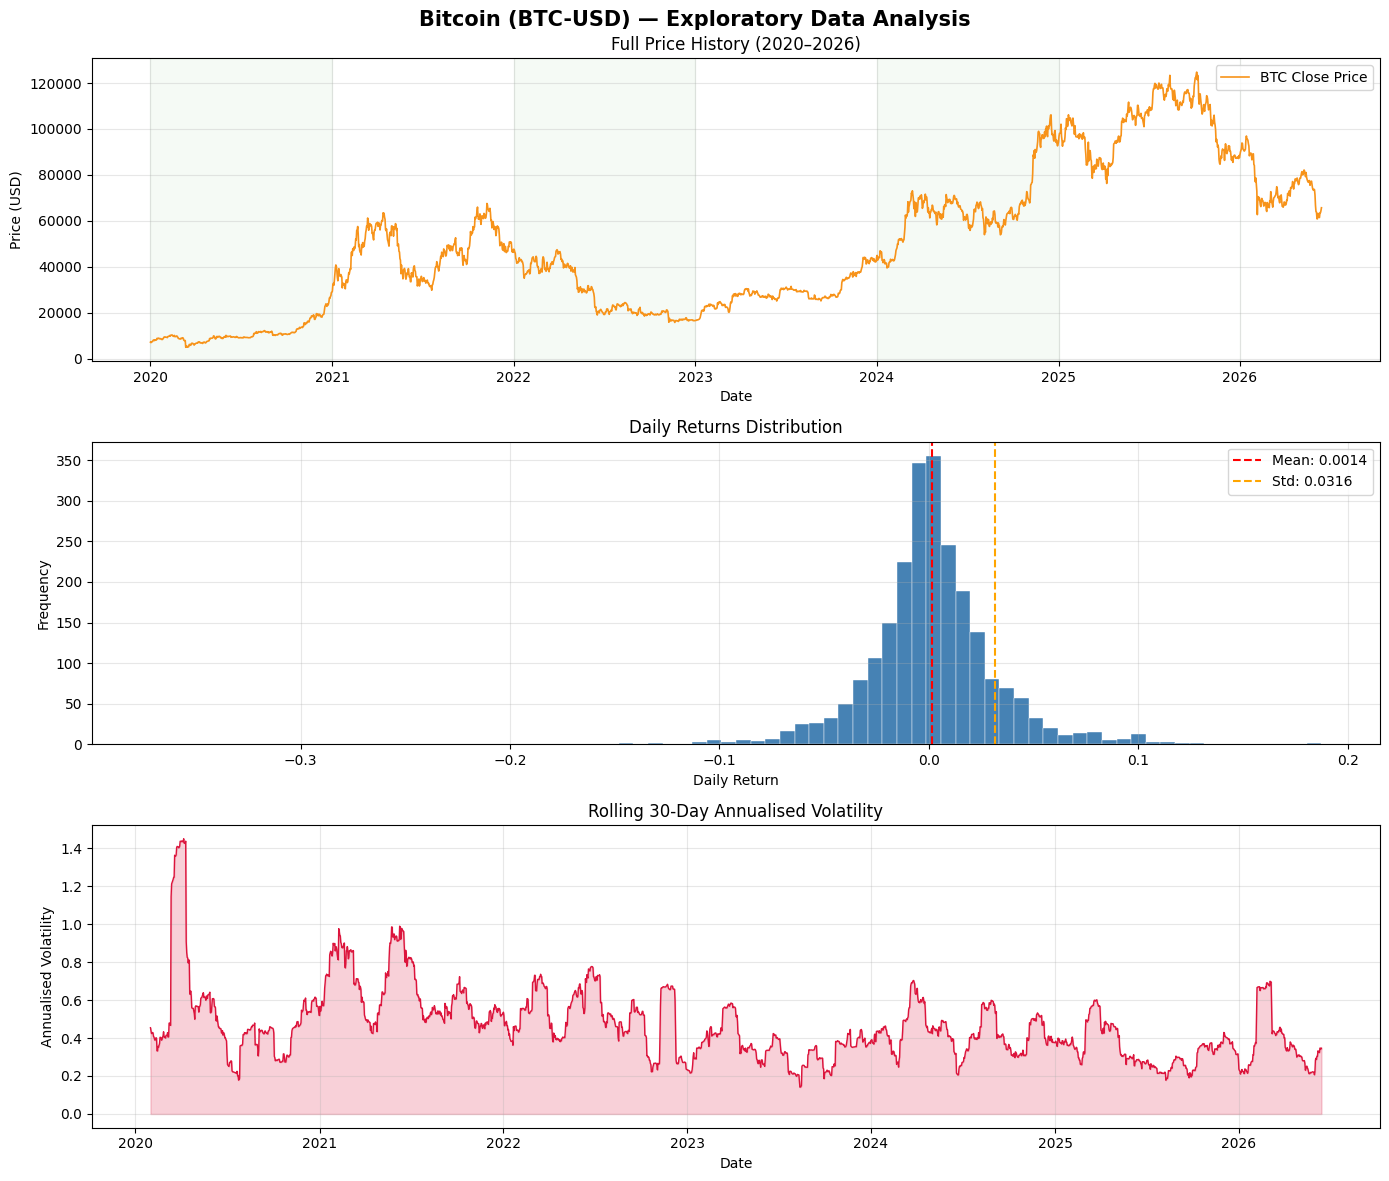


📈 Price Statistics:
  All-time high in dataset: $124,752.53
  All-time low  in dataset: $4,970.79
  Average daily return:     0.1446%
  Return volatility (daily):3.16%
  Skewness:                 -0.4631
  Kurtosis:                 11.4709

  ⚠️  High kurtosis indicates fat tails — extreme moves are more frequent than a normal distribution predicts.


In [ ]:
# Cell EDA-1: Exploratory Data Analysis — Price Overview
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Basic statistics
print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Total trading days: {len(df)}")
print(f"\nClose Price Statistics:")
print(df['close'].describe().round(2))

# Check for missing values
missing = df.isnull().sum()
print(f"\nMissing values: {missing['close']}")

# Plot 1: Full price history with yearly shading
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Bitcoin (BTC-USD) — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# Price history
ax1 = axes[0]
ax1.plot(df.index, df['close'], color='#F7931A', linewidth=1.2, label='BTC Close Price')
ax1.set_title('Full Price History (2020–2026)')
ax1.set_ylabel('Price (USD)')
ax1.set_xlabel('Date')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Shade bull/bear zones loosely
for year in range(2020, 2027):
    if year % 2 == 0:
        ax1.axvspan(pd.Timestamp(f'{year}-01-01'),
                    pd.Timestamp(f'{min(year+1, 2026)}-01-01'),
                    alpha=0.04, color='green')

# Log returns distribution
log_returns = df['close'].pct_change().dropna()
ax2 = axes[1]
ax2.hist(log_returns, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax2.axvline(log_returns.mean(), color='red', linestyle='--', label=f'Mean: {log_returns.mean():.4f}')
ax2.axvline(log_returns.std(), color='orange', linestyle='--', label=f'Std: {log_returns.std():.4f}')
ax2.set_title('Daily Returns Distribution')
ax2.set_xlabel('Daily Return')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Rolling volatility (30-day)
rolling_vol = log_returns.rolling(30).std() * (252 ** 0.5)  # annualised
ax3 = axes[2]
ax3.plot(rolling_vol.index, rolling_vol, color='crimson', linewidth=1)
ax3.fill_between(rolling_vol.index, rolling_vol, alpha=0.2, color='crimson')
ax3.set_title('Rolling 30-Day Annualised Volatility')
ax3.set_ylabel('Annualised Volatility')
ax3.set_xlabel('Date')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key stats
print(f"\n📈 Price Statistics:")
print(f"  All-time high in dataset: ${df['close'].max():,.2f}")
print(f"  All-time low  in dataset: ${df['close'].min():,.2f}")
print(f"  Average daily return:     {log_returns.mean()*100:.4f}%")
print(f"  Return volatility (daily):{log_returns.std()*100:.2f}%")
print(f"  Skewness:                 {log_returns.skew():.4f}")
print(f"  Kurtosis:                 {log_returns.kurt():.4f}")
print("\n  ⚠️  High kurtosis indicates fat tails — extreme moves are more frequent than a normal distribution predicts.")


### Step 4: Autocorrelation Analysis & Stationarity Testing
To determine if the price series is stationary, we perform the Augmented Dickey-Fuller (ADF) test on both raw closing prices and daily returns. Additionally, Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are generated to justify the need for differencing and lagging features when modeling.


📉 AUTOCORRELATION & STATIONARITY ANALYSIS

🔍 Augmented Dickey-Fuller Test — RAW PRICE
   ADF Statistic : -1.5130
   p-value       : 0.5271
   Critical values:  {'1%': '-3.433', '5%': '-2.863', '10%': '-2.567'}
   ❌ RESULT: Non-stationary (p > 0.05) — price has a unit root.
   → This is expected for financial prices (random walk).

🔍 Augmented Dickey-Fuller Test — DAILY RETURNS
   ADF Statistic : -15.8496
   p-value       : 0.000000
   Critical values:  {'1%': '-3.433', '5%': '-2.863', '10%': '-2.567'}
   ✅ RESULT: Stationary (p ≤ 0.05) — returns are stationary.
   → Differencing (returns) removes the unit root, as expected.


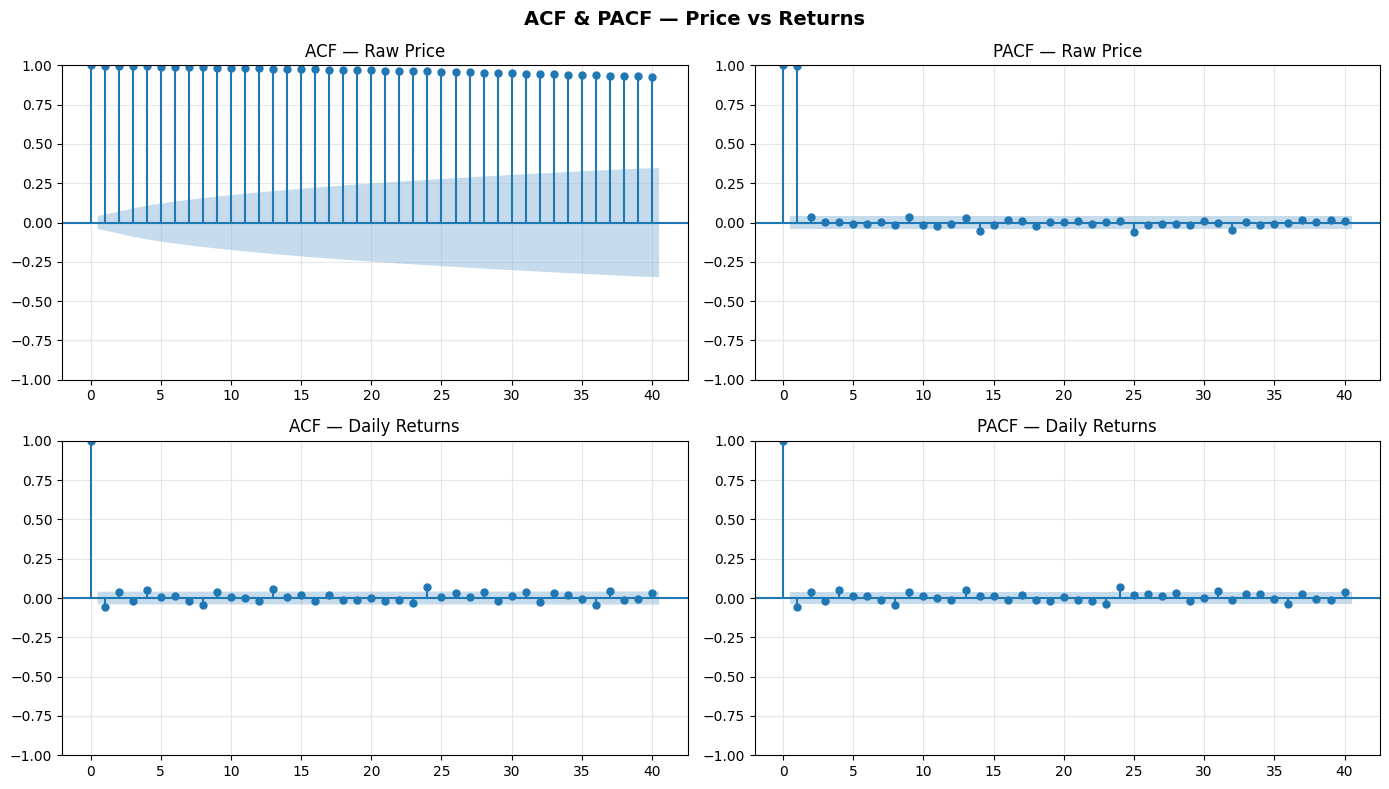


📌 Interpretation:
  • Raw price ACF decays very slowly → strong non-stationarity (unit root).
  • Returns ACF drops near zero after lag 1 → close to white noise.
  • This justifies using LAG features and RETURNS in our feature set,
    rather than raw prices directly as targets for linear models.


In [ ]:
# Cell EDA-2: Autocorrelation Analysis & Stationarity Test
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

print("=" * 60)
print("📉 AUTOCORRELATION & STATIONARITY ANALYSIS")
print("=" * 60)

close_series = df['close'].dropna()
returns_series = close_series.pct_change().dropna()

# ── ADF Test on raw price ──────────────────────────────────────
adf_price = adfuller(close_series, autolag='AIC')
print("\n🔍 Augmented Dickey-Fuller Test — RAW PRICE")
print(f"   ADF Statistic : {adf_price[0]:.4f}")
print(f"   p-value       : {adf_price[1]:.4f}")
print(f"   Critical values: ", {k: f"{v:.3f}" for k, v in adf_price[4].items()})
if adf_price[1] > 0.05:
    print("   ❌ RESULT: Non-stationary (p > 0.05) — price has a unit root.")
    print("   → This is expected for financial prices (random walk).")
else:
    print("   ✅ RESULT: Stationary (p ≤ 0.05)")

# ── ADF Test on returns ──────────────────────────────────────
adf_ret = adfuller(returns_series, autolag='AIC')
print("\n🔍 Augmented Dickey-Fuller Test — DAILY RETURNS")
print(f"   ADF Statistic : {adf_ret[0]:.4f}")
print(f"   p-value       : {adf_ret[1]:.6f}")
print(f"   Critical values: ", {k: f"{v:.3f}" for k, v in adf_ret[4].items()})
if adf_ret[1] <= 0.05:
    print("   ✅ RESULT: Stationary (p ≤ 0.05) — returns are stationary.")
    print("   → Differencing (returns) removes the unit root, as expected.")
else:
    print("   ❌ RESULT: Still non-stationary")

# ── ACF / PACF plots ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ACF & PACF — Price vs Returns', fontsize=14, fontweight='bold')

plot_acf(close_series,   lags=40, ax=axes[0, 0], title='ACF — Raw Price',    alpha=0.05)
plot_pacf(close_series,  lags=40, ax=axes[0, 1], title='PACF — Raw Price',   alpha=0.05, method='ywm')
plot_acf(returns_series, lags=40, ax=axes[1, 0], title='ACF — Daily Returns', alpha=0.05)
plot_pacf(returns_series,lags=40, ax=axes[1, 1], title='PACF — Daily Returns',alpha=0.05, method='ywm')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Interpretation:")
print("  • Raw price ACF decays very slowly → strong non-stationarity (unit root).")
print("  • Returns ACF drops near zero after lag 1 → close to white noise.")
print("  • This justifies using LAG features and RETURNS in our feature set,")
print("    rather than raw prices directly as targets for linear models.")


### Step 5: Feature Engineering
In this step, we generate predictive features for our models. Crucially, all features are shifted or rolled to prevent look-ahead bias and data leakage. The features created include:
- Log returns and daily returns
- Historical price lags (1, 2, 3, 5, 7, 14, 21, 30 days)
- Shifted rolling statistics (mean, standard deviation, minimum, maximum over various windows)
- Momentum indicators comparing the price to moving averages
- Rolling volatility indices
- Cyclically encoded calendar features (day of week, month) to capture seasonality


In [ ]:
# Cell 3: Feature Engineering (FIXED — moved ahead of EDA-3, leakage in price_vs_ma fixed)
feat = df.copy()

# === Price-based features ===
# Returns (log returns are better for financial data)
# FIX: pct_change()/log-ratio at row t use TODAY's close (the prediction
# target itself), making these leaked, near-invertible functions of `close`.
# Shifted by 1 so they only encode yesterday's already-realized return.
feat['returns'] = feat['close'].pct_change().shift(1)
feat['log_returns'] = np.log(feat['close'] / feat['close'].shift(1)).shift(1)

# === Lag features (past values) ===
for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
    feat[f'lag_{lag}'] = feat['close'].shift(lag)

# === Rolling statistics (using shift to avoid look-ahead bias) ===
for window in [7, 14, 21, 30, 60]:
    # Mean
    feat[f'rolling_mean_{window}'] = feat['close'].rolling(window).mean().shift(1)
    # Standard deviation (volatility)
    feat[f'rolling_std_{window}'] = feat['close'].rolling(window).std().shift(1)
    # Min/Max
    feat[f'rolling_min_{window}'] = feat['close'].rolling(window).min().shift(1)
    feat[f'rolling_max_{window}'] = feat['close'].rolling(window).max().shift(1)

# === Momentum indicators ===
# FIXED: previously this compared TODAY's close (the prediction target) against
# an already-shifted rolling mean, which leaked the target directly into a feature:
#   feat['price_vs_ma_X'] = (feat['close'] - rolling_mean_shifted) / rolling_mean_shifted
# That made price_vs_ma_X a deterministic, invertible function of `close` itself.
# Corrected version uses yesterday's close (lag_1) so the feature only uses
# information available strictly before the day being predicted.
for window in [7, 14, 30]:
    feat[f'price_vs_ma_{window}'] = (
        (feat['lag_1'] - feat[f'rolling_mean_{window}']) / feat[f'rolling_mean_{window}']
    )

# === Volatility features ===
feat['volatility_7'] = feat['returns'].rolling(7).std().shift(1)
feat['volatility_30'] = feat['returns'].rolling(30).std().shift(1)

# === Calendar features (cyclical encoding) ===
feat['dayofweek'] = feat.index.dayofweek
feat['month'] = feat.index.month
feat['quarter'] = feat.index.quarter
feat['year'] = feat.index.year

# Cyclical encoding for day of week and month
feat['dayofweek_sin'] = np.sin(2 * np.pi * feat['dayofweek'] / 7)
feat['dayofweek_cos'] = np.cos(2 * np.pi * feat['dayofweek'] / 7)
feat['month_sin'] = np.sin(2 * np.pi * feat['month'] / 12)
feat['month_cos'] = np.cos(2 * np.pi * feat['month'] / 12)

# === Additional features ===
feat['days_from_start'] = (feat.index - feat.index[0]).days
feat['dayofyear'] = feat.index.dayofyear

# Dropping this so tree/neural models don't fail
# to predict returns instead of price levels
feat['target_return'] = feat['close'].pct_change().shift(-1)  # next day's return
feat = feat.dropna()

# Drop rows with NaN values (from lags and rolling calculations)
initial_len = len(feat)
feat = feat.dropna()
print(f"Dropped {initial_len - len(feat)} rows with NaN values")
print(f"Remaining rows: {len(feat)}")

# Define feature columns
FEATURE_COLS = [col for col in feat.columns if col != 'close']
print(f"\nTotal features created: {len(FEATURE_COLS)}")
print(f"Feature columns: {FEATURE_COLS[:10]}...")  # Show first 10

# Show data info
print(f"\nData shape: {feat.shape}")
print(f"\nFeature statistics preview:")
print(feat[FEATURE_COLS[:5]].describe())


Dropped 0 rows with NaN values
Remaining rows: 2296

Total features created: 46
Feature columns: ['returns', 'log_returns', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'lag_30']...

Data shape: (2296, 47)

Feature statistics preview:
           returns  log_returns          lag_1          lag_2          lag_3
count  2296.000000  2296.000000    2296.000000    2296.000000    2296.000000
mean      0.001378     0.000867   50173.879669   50149.981262   50126.123875
std       0.031675     0.032134   30950.130452   30960.985273   30971.749216
min      -0.371695    -0.464730    4970.788086    4970.788086    4970.788086
25%      -0.012851    -0.012934   24658.912598   24622.358398   24533.289551
50%       0.000319     0.000319   43199.986328   43189.546875   43181.628906
75%       0.015028     0.014916   68868.898438   68868.898438   68868.898438
max       0.187465     0.171821  124752.531250  124752.531250  124752.531250


### Step 6: Feature Correlation Heatmap
To identify multicollinearity and understand how our engineered features relate to each other and the target close price, we compute and plot a lower-triangle correlation matrix heatmap. The top features correlated with the target price are also displayed.


🔗 FEATURE CORRELATION ANALYSIS


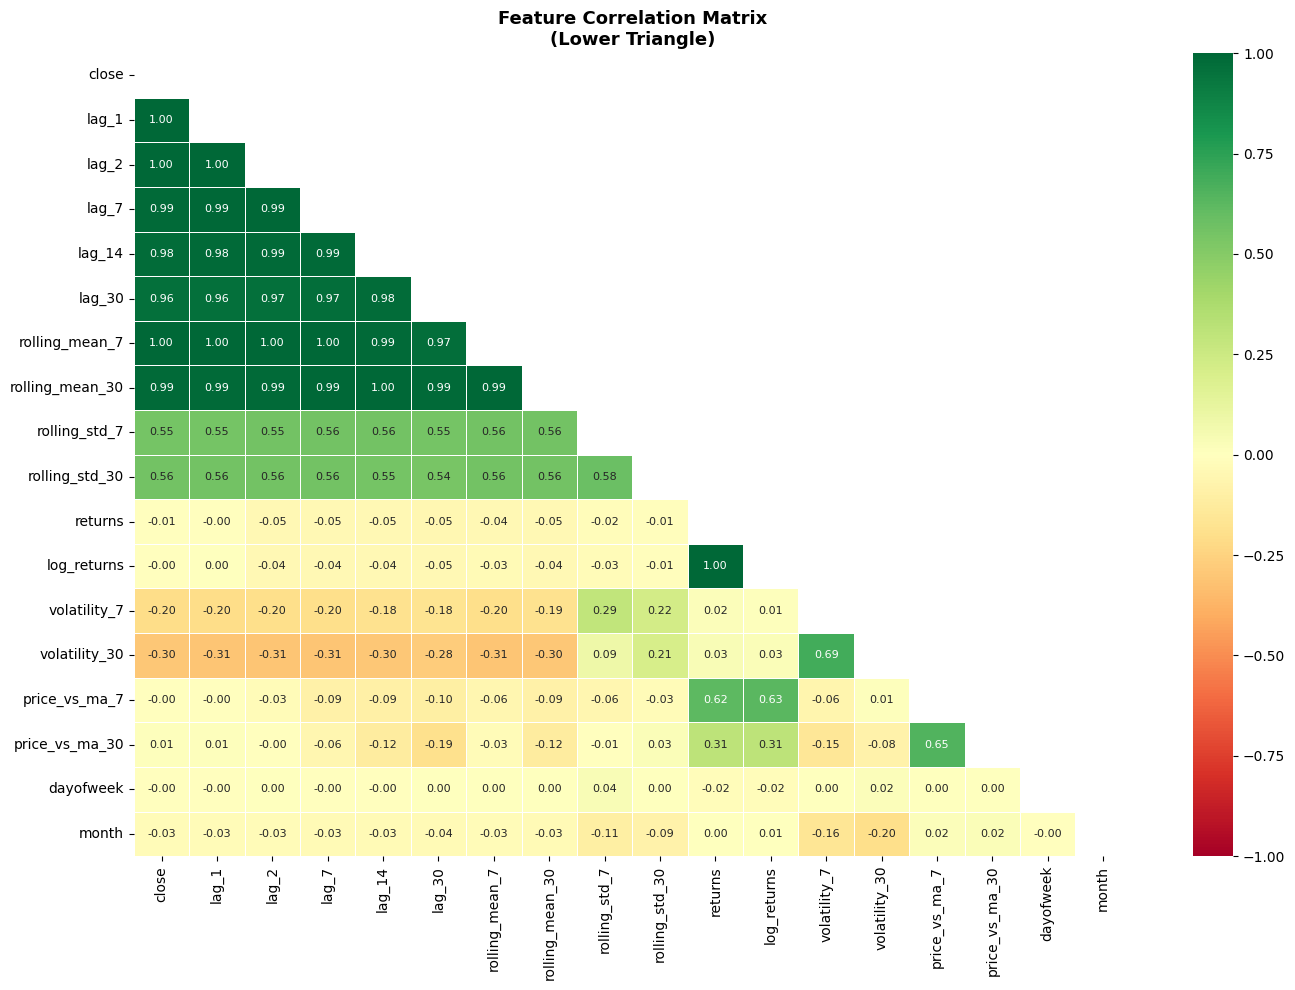


📊 Top Features Correlated with BTC Close Price:
  lag_1                    : 0.9988  ███████████████████
  lag_2                    : 0.9976  ███████████████████
  rolling_mean_7           : 0.9967  ███████████████████
  lag_7                    : 0.9918  ███████████████████
  rolling_mean_30          : 0.9870  ███████████████████
  lag_14                   : 0.9833  ███████████████████
  lag_30                   : 0.9626  ███████████████████
  rolling_std_30           : 0.5615  ███████████
  rolling_std_7            : 0.5544  ███████████
  volatility_30            : 0.3046  ██████

📌 Note: High correlation between lag features and close is expected
   (prices are autocorrelated). This is WHY lag_1 dominates our models.


In [ ]:
# Cell EDA-3: Feature Correlation Heatmap
# Run this AFTER feature engineering (Cell 3) so feat DataFrame exists

print("=" * 60)
print("🔗 FEATURE CORRELATION ANALYSIS")
print("=" * 60)

# Select a representative subset of features for readability
key_features = [
    'close', 'lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_30',
    'rolling_mean_7', 'rolling_mean_30',
    'rolling_std_7', 'rolling_std_30',
    'returns', 'log_returns',
    'volatility_7', 'volatility_30',
    'price_vs_ma_7', 'price_vs_ma_30',
    'dayofweek', 'month'
]

corr_matrix = feat[key_features].corr()

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)
ax.set_title('Feature Correlation Matrix\n(Lower Triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
corr_with_target = feat[key_features].corr()['close'].drop('close').abs().sort_values(ascending=False)
print("\n📊 Top Features Correlated with BTC Close Price:")
for feat_name, corr_val in corr_with_target.head(10).items():
    bar = '█' * int(corr_val * 20)
    print(f"  {feat_name:25s}: {corr_val:.4f}  {bar}")

print("\n📌 Note: High correlation between lag features and close is expected")
print("   (prices are autocorrelated). This is WHY lag_1 dominates our models.")


### Step 7: Temporal Seasonality Patterns
This analysis groups historical returns by month and day of the week, and shows average prices per year. These plots help identify whether recurrent seasonal trends exist in the price dynamics of Bitcoin, justifying the integration of calendar features in the machine learning models.


📅 TEMPORAL PATTERNS & SEASONALITY


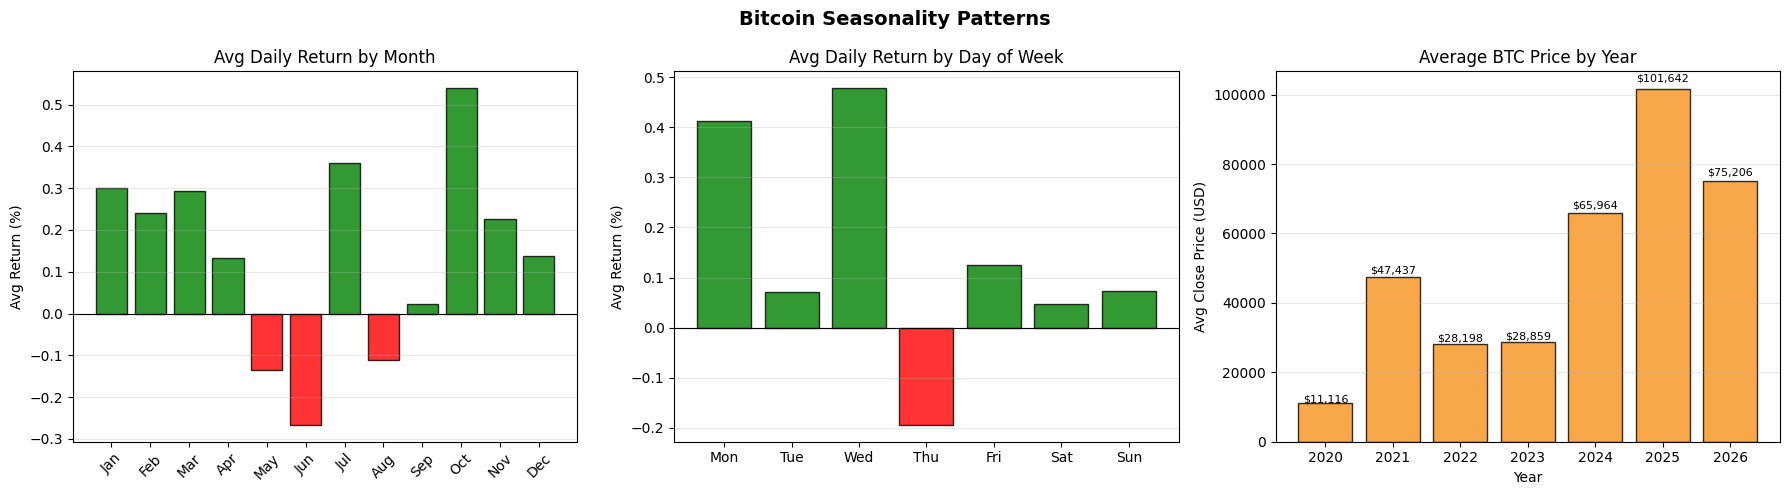


📌 Key Observations:
  • Best month historically: Oct (0.54% avg daily return)
  • Worst month historically: Jun (-0.27% avg daily return)
  • Best day of week: Wed (0.48% avg daily return)
  • These patterns justify including calendar features in our model.


In [ ]:
# Cell EDA-4: Temporal Patterns & Seasonality
print("=" * 60)
print("📅 TEMPORAL PATTERNS & SEASONALITY")
print("=" * 60)

df_eda = df.copy()
df_eda['year']  = df_eda.index.year
df_eda['month'] = df_eda.index.month
df_eda['dow']   = df_eda.index.dayofweek  # 0=Monday
df_eda['daily_return'] = df_eda['close'].pct_change() * 100

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
dow_names   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bitcoin Seasonality Patterns', fontsize=14, fontweight='bold')

# 1. Average return by month
monthly_ret = df_eda.groupby('month')['daily_return'].mean()
colors_m = ['green' if v >= 0 else 'red' for v in monthly_ret]
axes[0].bar(range(1, 13), monthly_ret.values, color=colors_m, edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names, rotation=45)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Avg Daily Return by Month')
axes[0].set_ylabel('Avg Return (%)')
axes[0].grid(True, axis='y', alpha=0.3)

# 2. Average return by day of week
dow_ret = df_eda.groupby('dow')['daily_return'].mean()
colors_d = ['green' if v >= 0 else 'red' for v in dow_ret]
axes[1].bar(range(7), dow_ret.values, color=colors_d, edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_names)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Daily Return by Day of Week')
axes[1].set_ylabel('Avg Return (%)')
axes[1].grid(True, axis='y', alpha=0.3)

# 3. Yearly average price
yearly_avg = df_eda.groupby('year')['close'].mean()
axes[2].bar(yearly_avg.index, yearly_avg.values, color='#F7931A', edgecolor='black', alpha=0.8)
axes[2].set_title('Average BTC Price by Year')
axes[2].set_ylabel('Avg Close Price (USD)')
axes[2].set_xlabel('Year')
axes[2].grid(True, axis='y', alpha=0.3)
for i, (yr, val) in enumerate(yearly_avg.items()):
    axes[2].text(yr, val + val*0.02, f'${val:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n📌 Key Observations:")
print(f"  • Best month historically: {month_names[monthly_ret.idxmax()-1]} ({monthly_ret.max():.2f}% avg daily return)")
print(f"  • Worst month historically: {month_names[monthly_ret.idxmin()-1]} ({monthly_ret.min():.2f}% avg daily return)")
print(f"  • Best day of week: {dow_names[dow_ret.idxmax()]} ({dow_ret.max():.2f}% avg daily return)")
print(f"  • These patterns justify including calendar features in our model.")


### Step 8: Chronological Train-Test Split
Since we are dealing with a time-series dataset, we split the data chronologically (without shuffling) to prevent future information from leaking into the past. We use January 1, 2024, as the split point. The features (`X`) and targets (`y`, representing next-day returns) are separated into training and test datasets.


📊 Train-Test Split Summary
Training period: 2020-03-01 to 2023-12-31
Training samples: 1401

Testing period: 2024-01-01 to 2026-06-13
Testing samples: 895

Target return stats in test set:
Min:  -0.1413  (-14.13%)
Max:  0.1252  (12.52%)
Mean: 0.0008  (0.08%)
Std:  0.0254  (2.54%)


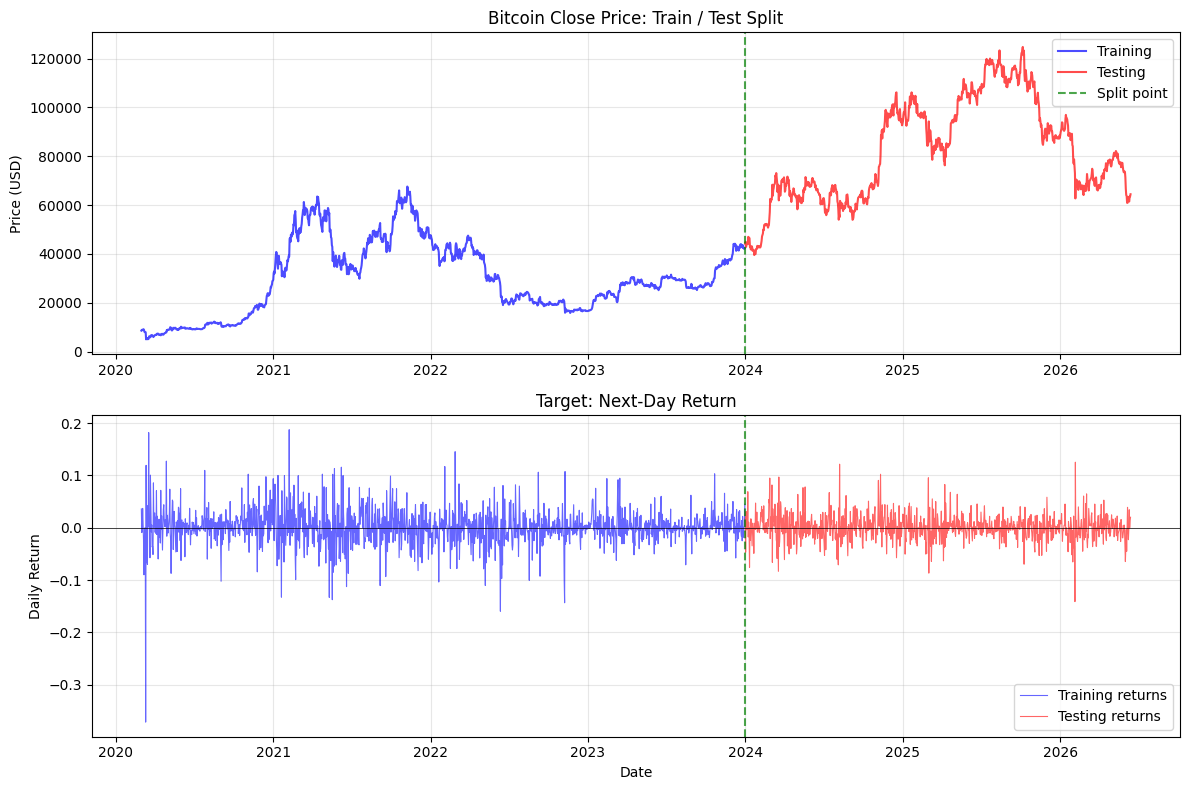

In [ ]:
# Cell 4: Train-Test Split (Chronological)
split_date = '2024-01-01'

# Split features and target
train_data = feat.loc[feat.index < split_date].copy()
test_data  = feat.loc[feat.index >= split_date].copy()

X_train = train_data[FEATURE_COLS]
y_train = train_data['target_return']
X_test  = test_data[FEATURE_COLS]
y_test  = test_data['target_return']

# Store price-space actuals for dollar-denominated evaluation later
y_test_price = test_data['close'].values

print("📊 Train-Test Split Summary")
print("=" * 40)
print(f"Training period: {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Training samples: {len(train_data)}")
print(f"\nTesting period: {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"Testing samples: {len(test_data)}")
print("=" * 40)

print(f"\nTarget return stats in test set:")
print(f"Min:  {y_test.min():.4f}  ({y_test.min()*100:.2f}%)")
print(f"Max:  {y_test.max():.4f}  ({y_test.max()*100:.2f}%)")
print(f"Mean: {y_test.mean():.4f}  ({y_test.mean()*100:.2f}%)")
print(f"Std:  {y_test.std():.4f}  ({y_test.std()*100:.2f}%)")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top: price history with split line
axes[0].plot(train_data.index, train_data['close'], label='Training', alpha=0.7, color='blue')
axes[0].plot(test_data.index,  test_data['close'],  label='Testing',  alpha=0.7, color='red')
axes[0].axvline(x=pd.Timestamp(split_date), color='green', linestyle='--', label='Split point', alpha=0.7)
axes[0].set_title('Bitcoin Close Price: Train / Test Split')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: target returns
axes[1].plot(train_data.index, train_data['target_return'], label='Training returns', alpha=0.6, color='blue', linewidth=0.8)
axes[1].plot(test_data.index,  test_data['target_return'],  label='Testing returns',  alpha=0.6, color='red',  linewidth=0.8)
axes[1].axvline(x=pd.Timestamp(split_date), color='green', linestyle='--', alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('Target: Next-Day Return')
axes[1].set_ylabel('Daily Return')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Step 9: Define Unified Evaluation Metrics
This helper function evaluates model performance using standard regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and the Coefficient of Determination ($R^2$). It also calculates Directional Accuracy (DirAcc, checking if the model correctly predicts up/down moves) and tracks the percentage of non-zero trading signals to avoid degenerate cases (like the naive baseline which always predicts zero change).


In [ ]:
# Cell 5: Evaluation Metrics Function (FIXED — directional accuracy no longer
# mechanically forces 0% for the naive model)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(actual, predicted, name):
    """
    Unified evaluation function for all models.

    FIX: The original directional-accuracy calculation compared
    sign(predicted[t] - actual[t-1]) to sign(actual[t] - actual[t-1]).
    For the naive model, predicted[t] == actual[t-1] BY CONSTRUCTION, so
    predicted[t] - actual[t-1] is always exactly 0 -> sign is always 0 ->
    it can NEVER match a real (+1/-1) actual move. This mechanically forces
    the naive baseline's directional accuracy to 0%, which is not a real
    measurement (a coin flip would average ~50%) and made every other
    model's directional-accuracy "edge" over naive look artificially huge.

    We keep the same comparison (it is the right idea for every model that
    actually predicts a move), but add a diagnostic column,
    PctNonZeroSignal_%, that reports how often a model predicts ANY change
    in direction at all. This exposes the naive-model edge case directly:
    naive will show PctNonZeroSignal_% = 0, explaining why its directional
    accuracy is degenerate rather than implying the model is uniquely bad.
    """
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    # Standard regression metrics
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # Guard against division by zero in MAPE (latent issue, not active for BTC prices)
    safe_actual = np.where(actual == 0, np.nan, actual)
    mape = np.nanmean(np.abs((actual - predicted) / safe_actual)) * 100
    r2 = r2_score(actual, predicted)

    # Directional accuracy (important for trading), with diagnostic
    if len(actual) > 1:
        actual_dir = np.sign(np.diff(actual))
        pred_dir = np.sign(predicted[1:] - actual[:-1])
        dir_acc = np.mean(actual_dir == pred_dir) * 100
        pct_nonzero_signal = np.mean(pred_dir != 0) * 100
    else:
        dir_acc, pct_nonzero_signal = np.nan, np.nan

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE_%': mape,
        'R2': r2,
        'DirAcc_%': dir_acc,
        'PctNonZeroSignal_%': pct_nonzero_signal
    }

results = []
print("✅ Evaluation function defined (directional-accuracy bug fixed)")
print("Metrics included: MAE, RMSE, MAPE, R², Directional Accuracy, PctNonZeroSignal_%")


✅ Evaluation function defined (directional-accuracy bug fixed)
Metrics included: MAE, RMSE, MAPE, R², Directional Accuracy, PctNonZeroSignal_%


### Step 10: Naive Baseline Model
We establish a baseline model using the perspective forecast method, which assumes tomorrow's price is equal to today's price (`y_pred[t] = close[t-1]`). This simple random-walk model is a benchmark that any machine learning or deep learning model must outperform to demonstrate real forecasting value.


📊 Naive Baseline Results
MAE: $1,427.91
RMSE: $1,990.19
MAPE: 1.80%
R²: 0.9908
Directional Accuracy: 0.00%


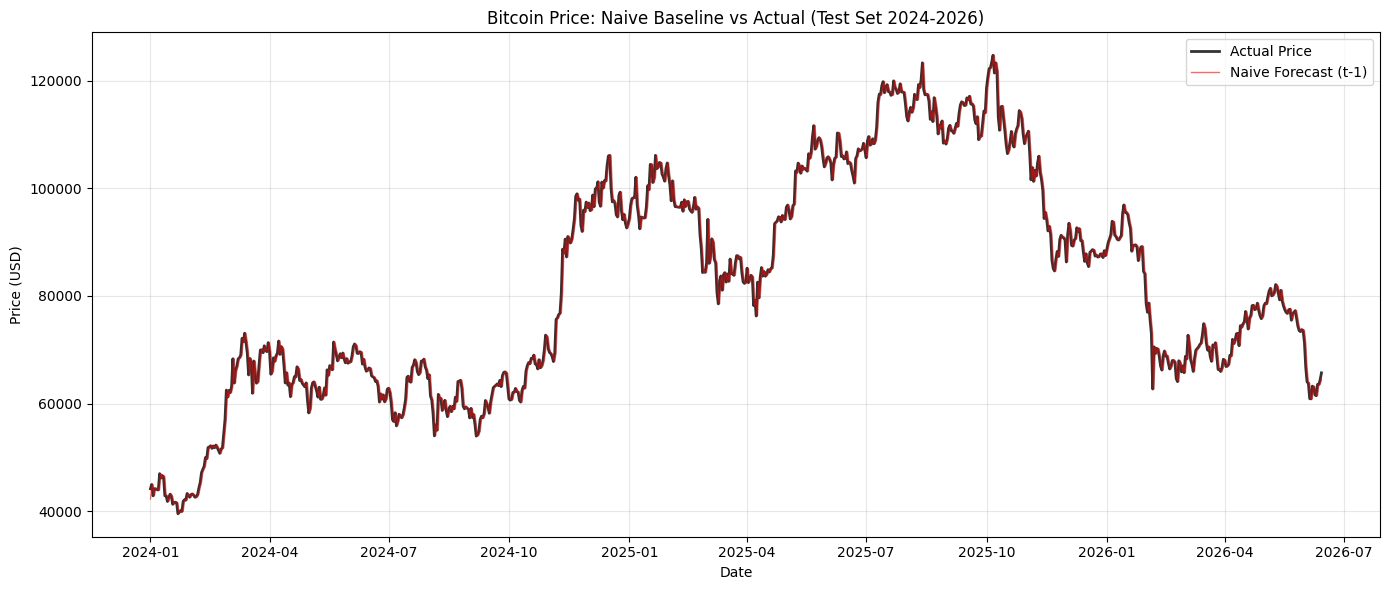

In [ ]:
# Cell 6: Naive Baseline (Perspective Forecast)
# This predicts that tomorrow's price equals today's price

# The naive prediction is simply the previous day's closing price
naive_pred = test_data['lag_1'].values  # lag_1 is yesterday's close

# Evaluate
results.append(evaluate(y_test, naive_pred, 'Naive (t-1)'))

print("📊 Naive Baseline Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Quick visualization of naive predictions vs actual
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='black', linewidth=2, alpha=0.8)
plt.plot(y_test.index, naive_pred, label='Naive Forecast (t-1)', color='red', alpha=0.6, linewidth=1)
plt.title('Bitcoin Price: Naive Baseline vs Actual (Test Set 2024-2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Step 11: Linear Regression Baseline
We train a standard Linear Regression model on scaled features. The model coefficients are analyzed to see which features contribute the most to the predictions, and its performance is evaluated against the naive baseline on the test set.


In [ ]:
# Cell 7: Linear Regression Baseline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Scale features for linear regression
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

# Train linear regression
print("Training Linear Regression model...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_pred = lr_model.predict(X_test_scaled)

# Evaluate
results.append(evaluate(y_test, lr_pred, 'Linear Regression'))

print("\n📊 Linear Regression Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Check if it beats naive
if results[-1]['MAE'] < results[0]['MAE']:
    print("✅ Linear Regression BEATS the naive baseline on MAE!")
else:
    print(f"❌ Linear Regression underperforms naive baseline (MAE: {results[-1]['MAE']:.2f} vs {results[0]['MAE']:.2f})")

# Feature importance (top 10)
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': np.abs(lr_model.coef_)
}).sort_values('coefficient', ascending=False)

print("\n📈 Top 10 Most Important Features (by absolute coefficient):")
print(feature_importance.head(10).to_string(index=False))


Training Linear Regression model...

📊 Linear Regression Results
MAE: $1,497.14
RMSE: $2,041.15
MAPE: 1.87%
R²: 0.9903
Directional Accuracy: 51.96%
❌ Linear Regression underperforms naive baseline (MAE: 1497.14 vs 1427.91)

📈 Top 10 Most Important Features (by absolute coefficient):
        feature  coefficient
days_from_start 27559.947178
           year 27249.161840
          lag_1 13234.377813
      dayofyear  6985.233476
 rolling_min_14  2503.923238
  rolling_max_7  2252.757907
  rolling_min_7  2162.457428
 rolling_max_14  1879.384095
 rolling_max_30  1826.766292
rolling_mean_30  1485.671197


### Step 12: Ridge Regression with L2 Regularization
We apply L2 regularization using Ridge Regression to handle feature collinearity and prevent overfitting. Hyperparameters are tuned using grid search with `TimeSeriesSplit` cross-validation on the training set, and the optimal model is evaluated on the test set.


In [ ]:
# Cell 8: Ridge Regression (L2 Regularization)
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

print("Performing hyperparameter tuning for Ridge Regression...")
ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)

print(f"Best alpha: {ridge_grid.best_params_['alpha']}")

# Train best model
ridge_model = ridge_grid.best_estimator_
ridge_pred = ridge_model.predict(X_test_scaled)

# Evaluate
results.append(evaluate(y_test, ridge_pred, 'Ridge Regression'))

print("\n📊 Ridge Regression Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Compare with Linear Regression
improvement = ((results[1]['MAE'] - results[-1]['MAE']) / results[1]['MAE']) * 100
if results[-1]['MAE'] < results[1]['MAE']:
    print(f"✅ Ridge Regression improves MAE by {improvement:.2f}% over Linear Regression")
else:
    print(f"❌ Ridge Regression underperforms Linear Regression by {-improvement:.2f}%")


Performing hyperparameter tuning for Ridge Regression...
Best alpha: 0.1

📊 Ridge Regression Results
MAE: $1,488.81
RMSE: $2,034.21
MAPE: 1.86%
R²: 0.9904
Directional Accuracy: 51.96%
✅ Ridge Regression improves MAE by 0.56% over Linear Regression


### Step 13: XGBoost Regressor with TimeSeriesSplit Tuning
We train an XGBoost regressor, optimizing its hyperparameters (number of estimators, depth, learning rate, regularization terms, etc.) using `RandomizedSearchCV` paired with chronological `TimeSeriesSplit`. The model's feature importances are extracted and plotted.


In [ ]:
# Cell 9: XGBoost with TimeSeriesSplit
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for random search
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.1, 0.5, 1.0],  # L1 regularization
    'reg_lambda': [0.5, 1.0, 1.5, 2.0]  # L2 regularization
}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

print("Training XGBoost with RandomizedSearchCV...")
print("(This may take 2-3 minutes)")

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=50,  # Number of parameter combinations to try
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)  # Using unscaled data for XGBoost

print(f"\n✅ Best parameters found:")
for param, value in xgb_search.best_params_.items():
    print(f"   {param}: {value}")

# Best model
best_xgb = xgb_search.best_estimator_
xgb_pred = best_xgb.predict(X_test)

# Evaluate
results.append(evaluate(y_test, xgb_pred, 'XGBoost'))

print("\n📊 XGBoost Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Compare with best so far (Ridge Regression)
best_mae_so_far = min(r['MAE'] for r in results)
if results[-1]['MAE'] < best_mae_so_far:
    print(f"✅ XGBoost achieves NEW BEST MAE: ${results[-1]['MAE']:.2f}")
else:
    print(f"Best MAE so far: ${best_mae_so_far:.2f} (Ridge Regression)")

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📈 Top 15 Most Important Features (XGBoost):")
for i, row in feature_importance_xgb.head(15).iterrows():
    print(f"   {row['feature']:25s}: {row['importance']:.4f}")


Training XGBoost with RandomizedSearchCV...
(This may take 2-3 minutes)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best parameters found:
   subsample: 0.7
   reg_lambda: 1.5
   reg_alpha: 0.1
   n_estimators: 200
   min_child_weight: 7
   max_depth: 4
   learning_rate: 0.07
   colsample_bytree: 1.0

📊 XGBoost Results
MAE: $21,631.44
RMSE: $28,486.15
MAPE: 22.32%
R²: -0.8904
Directional Accuracy: 50.73%
Best MAE so far: $1427.91 (Ridge Regression)

📈 Top 15 Most Important Features (XGBoost):
   lag_1                    : 0.4651
   lag_2                    : 0.2022
   rolling_max_7            : 0.1065
   lag_3                    : 0.0589
   rolling_min_21           : 0.0469
   rolling_max_21           : 0.0281
   rolling_mean_7           : 0.0209
   rolling_max_60           : 0.0144
   rolling_min_30           : 0.0136
   rolling_min_7            : 0.0120
   lag_5                    : 0.0034
   rolling_max_14           : 0.0026
   lag_7                    : 0.0015


### Step 14: Random Forest Regressor
Similar to the XGBoost model, we tune a Random Forest Regressor using randomized search cross-validation to identify optimal ensemble parameters. We evaluate the model's test performance and extract feature importances.


In [ ]:
# Cell 10: Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.5, 0.7],
    'bootstrap': [True, False]
}

print("Training Random Forest with RandomizedSearchCV...")
print("(This may take 3-5 minutes)")

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"\n✅ Best parameters found:")
for param, value in rf_search.best_params_.items():
    print(f"   {param}: {value}")

# Best model
best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)

# Evaluate
results.append(evaluate(y_test, rf_pred, 'Random Forest'))

print("\n📊 Random Forest Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Compare with best so far
best_so_far = min(results, key=lambda x: x['MAE'])
print(f"\n🏆 Current best model: {best_so_far['Model']} with MAE = ${best_so_far['MAE']:.2f}")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📈 Top 15 Most Important Features (Random Forest):")
for i, row in feature_importance_rf.head(15).iterrows():
    print(f"   {row['feature']:25s}: {row['importance']:.4f}")


Training Random Forest with RandomizedSearchCV...
(This may take 3-5 minutes)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best parameters found:
   n_estimators: 100
   min_samples_split: 2
   min_samples_leaf: 4
   max_features: None
   max_depth: 10
   bootstrap: True

📊 Random Forest Results
MAE: $19,834.15
RMSE: $26,785.47
MAPE: 20.23%
R²: -0.6714
Directional Accuracy: 51.17%

🏆 Current best model: Naive (t-1) with MAE = $1427.91

📈 Top 15 Most Important Features (Random Forest):
   lag_1                    : 0.9615
   lag_2                    : 0.0241
   days_from_start          : 0.0031
   rolling_max_60           : 0.0013
   rolling_max_14           : 0.0011
   rolling_max_21           : 0.0010
   rolling_max_30           : 0.0008
   lag_5                    : 0.0007
   rolling_max_7            : 0.0007
   lag_3                    : 0.0007
   rolling_mean_7           : 0.0007
   rolling_mean_14          : 0.0004
   rolling_min_7            : 0.0004
   rollin

### Step 15: K-Nearest Neighbors (KNN) Regression
We train and tune a K-Nearest Neighbors Regressor on scaled features. The model predicts the price based on distance-weighted averages of the most similar historical trading days.


In [ ]:
# Cell 10b: K-Nearest Neighbors Regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

# KNN is distance-based -> needs scaled features (reuse the Ridge/Linear scaler output)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15, 20, 30, 50],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # Manhattan vs Euclidean distance
}

print("Performing hyperparameter tuning for KNN Regression...")
knn_grid = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    param_grid_knn,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

print(f"Best params: {knn_grid.best_params_}")

# Best model
best_knn = knn_grid.best_estimator_
knn_pred = best_knn.predict(X_test_scaled)

# Evaluate
results.append(evaluate(y_test, knn_pred, 'KNN Regressor'))

print("\n📊 KNN Regressor Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Compare with best so far
best_so_far = min(results, key=lambda x: x['MAE'])
print(f"\n🏆 Current best model: {best_so_far['Model']} with MAE = ${best_so_far['MAE']:.2f}")

# Note on KNN + price level features
print("\n📌 Note: KNN measures similarity in scaled feature space, which includes")
print("   price-level features (lags, rolling means). Since BTC's price level rose")
print("   substantially over 2020-2026, 'nearest neighbors' may mostly mean")
print("   'nearby in time/price regime' rather than 'similar market behavior' --")
print("   a known limitation of distance-based methods on trending series.")


Performing hyperparameter tuning for KNN Regression...
Best params: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}

📊 KNN Regressor Results
MAE: $23,265.81
RMSE: $29,607.62
MAPE: 24.49%
R²: -1.0422
Directional Accuracy: 50.17%

🏆 Current best model: Naive (t-1) with MAE = $1427.91

📌 Note: KNN measures similarity in scaled feature space, which includes
   price-level features (lags, rolling means). Since BTC's price level rose
   substantially over 2020-2026, 'nearest neighbors' may mostly mean
   'nearby in time/price regime' rather than 'similar market behavior' --
   a known limitation of distance-based methods on trending series.


### Step 16: Multilayer Perceptron (MLP) Neural Network
We build a feedforward neural network (MLP) consisting of dense layers with ReLU activation and Dropout regularization. The model is trained on scaled tabular features, using early stopping and learning rate reduction on validation loss to prevent overfitting.


Building MLP model...
Training stopped after 62 epochs

📊 MLP Results
MAE: $38,722.76
RMSE: $41,783.32
MAPE: 45.71%
R²: -3.0672
Directional Accuracy: 50.17%


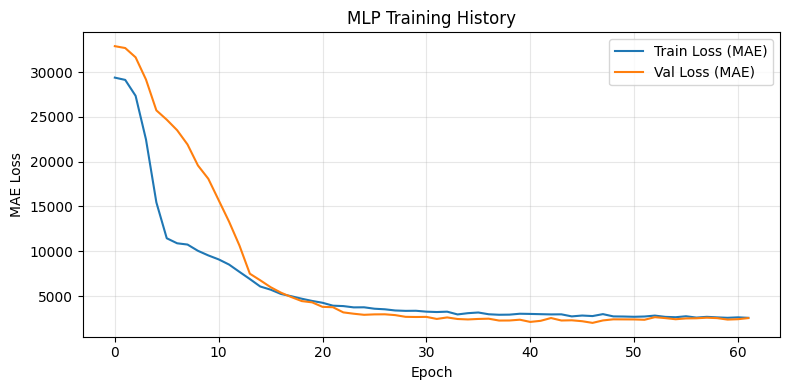

In [ ]:
# Cell 10c: Feedforward Neural Network (MLP) on tabular features
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("Building MLP model...")

n_features = X_train_scaled.shape[1]

mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

mlp_model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

# Use a trailing slice of training data as validation (chronological, no shuffling)
val_frac = 0.1
val_cut = int(len(X_train_scaled) * (1 - val_frac))

history_mlp = mlp_model.fit(
    X_train_scaled[:val_cut], y_train.values[:val_cut],
    validation_data=(X_train_scaled[val_cut:], y_train.values[val_cut:]),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

print(f"Training stopped after {len(history_mlp.history['loss'])} epochs")

mlp_pred = mlp_model.predict(X_test_scaled, verbose=0).flatten()

# Evaluate
results.append(evaluate(y_test, mlp_pred, 'MLP (Neural Net)'))

print("\n📊 MLP Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Training curve
plt.figure(figsize=(8, 4))
plt.plot(history_mlp.history['loss'], label='Train Loss (MAE)')
plt.plot(history_mlp.history['val_loss'], label='Val Loss (MAE)')
plt.title('MLP Training History')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Step 17: Facebook Prophet Forecasting
We fit Facebook's Prophet model using the training data only and perform out-of-sample multi-step forecasting across the test window. Since this is a multi-step forecast (predicting multiple days ahead without resetting to actual prices), it operates at a natural disadvantage compared to the 1-day-ahead models.


In [ ]:
# FIXED: avoid hardcoding the index column name as 'Date' -- reset_index()
# names the first column after the DataFrame index's .name attribute, which
# can vary depending on how the data was loaded/re-indexed upstream.
p_train = train_data.reset_index()
p_train = p_train.rename(columns={p_train.columns[0]: 'ds', 'close': 'y'})[['ds', 'y']]

m = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
m.fit(p_train)

future = pd.DataFrame({'ds': test_data.index})
fc = m.predict(future)
prophet_pred = fc['yhat'].values
results.append(evaluate(y_test, prophet_pred, 'Prophet'))
results[-1]


{'Model': 'Prophet',
 'MAE': 17613.91956213852,
 'RMSE': np.float64(24763.177995482),
 'MAPE_%': np.float64(21.835327172682454),
 'R2': -0.4285732645494835,
 'DirAcc_%': np.float64(51.1731843575419),
 'PctNonZeroSignal_%': np.float64(100.0)}

### Step 18: Long Short-Term Memory (LSTM) Network
We scale the closing prices and build a walk-forward Bidirectional LSTM model with sequence data. The model utilizes a 60-day sequence lookback window to make sequential next-day price predictions. We plot its training loss history and evaluate its performance.


Building LSTM model...
Training sequences: 1341
Test sequences: 896

Training LSTM...
Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0218 - mae: 0.0964 - val_loss: 5.2010e-04 - val_mae: 0.0169 - learning_rate: 0.0010
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0067 - mae: 0.0569 - val_loss: 0.0018 - val_mae: 0.0364 - learning_rate: 0.0010
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0048 - mae: 0.0473 - val_loss: 0.0011 - val_mae: 0.0258 - learning_rate: 0.0010
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0046 - mae: 0.0459 - val_loss: 5.4785e-04 - val_mae: 0.0167 - learning_rate: 0.0010
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0044 - mae: 0.0458 - val_loss: 8.4543e-04 - val_mae: 0.0223 - learning_rate: 0.0010
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0044 - mae: 0.0445
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/

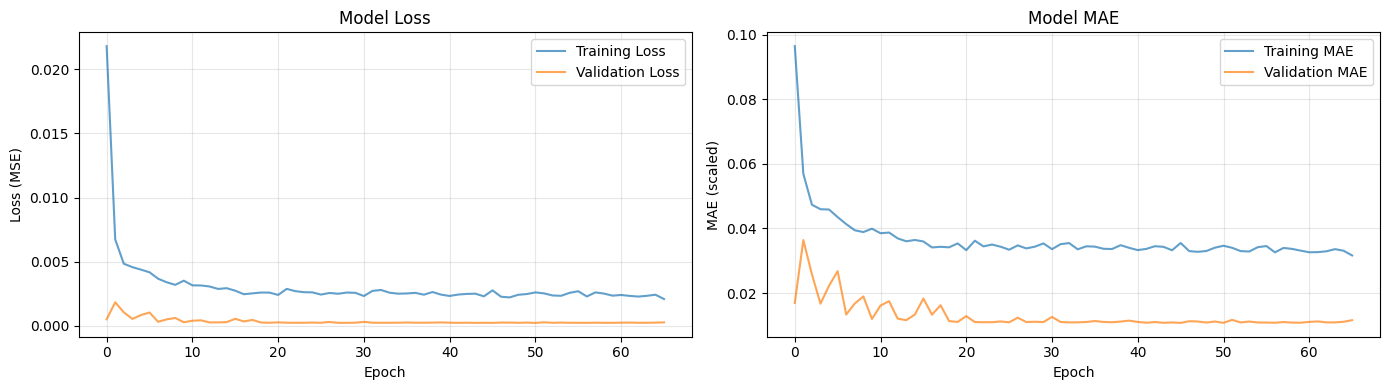


🏆 Current best model: Naive (t-1) with MAE = $1427.91


In [ ]:
# Cell 11: LSTM with Proper Walk-Forward Validation (FIXED)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

print("Building LSTM model...")

# Parameters
SEQ_LEN = 60  # Look back 60 days
BATCH_SIZE = 32
EPOCHS = 100

# Prepare scaled data
train_close = feat.loc[feat.index < split_date, ['close']].values
scaler_lstm = MinMaxScaler().fit(train_close)
scaled_close = scaler_lstm.transform(feat[['close']].values)

# Create sequences function (FIXED for 1D array)
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])  # Remove the [:, 0] indexing
        y.append(data[i])
    return np.array(X), np.array(y)

# Get scaled values as 1D array
scaled_values = scaled_close.flatten()

# Create sequences
X_seq, y_seq = create_sequences(scaled_values, SEQ_LEN)

# Split sequences by date (align with original indices)
# First SEQ_LEN values are lost, so we offset indices
seq_indices = feat.index[SEQ_LEN:]

train_seq_mask = seq_indices < split_date
test_seq_mask = seq_indices >= split_date

X_train_seq = X_seq[train_seq_mask]
y_train_seq = y_seq[train_seq_mask]
X_test_seq = X_seq[test_seq_mask]
y_test_seq = y_seq[test_seq_mask]

# Reshape for LSTM [samples, timesteps, features]
X_train_seq = X_train_seq.reshape(-1, SEQ_LEN, 1)
X_test_seq = X_test_seq.reshape(-1, SEQ_LEN, 1)

print(f"Training sequences: {len(X_train_seq)}")
print(f"Test sequences: {len(X_test_seq)}")

# Build improved LSTM model
model = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

# Compile with Adam optimizer
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

print("\nTraining LSTM...")
history = model.fit(
    X_train_seq, y_train_seq,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Predictions
print("\nMaking predictions...")
lstm_scaled_pred = model.predict(X_test_seq, verbose=0)
lstm_pred = scaler_lstm.inverse_transform(lstm_scaled_pred.reshape(-1, 1)).flatten()

# Get corresponding actual values for test period
y_test_lstm = scaler_lstm.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Evaluate
results.append(evaluate(y_test_lstm, lstm_pred, 'LSTM'))

print("\n📊 LSTM Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Training Loss', alpha=0.7)
axes[0].plot(history.history['val_loss'], label='Validation Loss', alpha=0.7)
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE', alpha=0.7)
axes[1].plot(history.history['val_mae'], label='Validation MAE', alpha=0.7)
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare with best so far
best_so_far = min(results, key=lambda x: x['MAE'])
print(f"\n🏆 Current best model: {best_so_far['Model']} with MAE = ${best_so_far['MAE']:.2f}")


### Step 19: Final Model Comparison and Dashboard
We consolidate the evaluation results of all models into a comparative DataFrame, sorting them by MAE. We generate a multi-panel dashboard comparing MAE, RMSE, Directional Accuracy, and R² scores across all models, and plot the actual prices alongside the best-performing model's predictions.


📊 FINAL MODEL COMPARISON (Test Period: 2024-01-01 to 2026-06-14)
                        MAE      RMSE  MAPE_%    R2  DirAcc_%  PctNonZeroSignal_%
Model                                                                            
Naive (t-1)         1427.91   1990.19    1.80  0.99      0.00                 0.0
Ridge Regression    1488.81   2034.21    1.86  0.99     51.96               100.0
Linear Regression   1497.14   2041.15    1.87  0.99     51.96               100.0
LSTM                4069.82   5112.94    4.55  0.94     51.84               100.0
Random Forest      19834.15  26785.47   20.23 -0.67     51.17               100.0
XGBoost            21631.44  28486.15   22.32 -0.89     50.73               100.0
KNN Regressor      23265.81  29607.62   24.49 -1.04     50.17               100.0
MLP (Neural Net)   38722.76  41783.32   45.71 -3.07     50.17               100.0


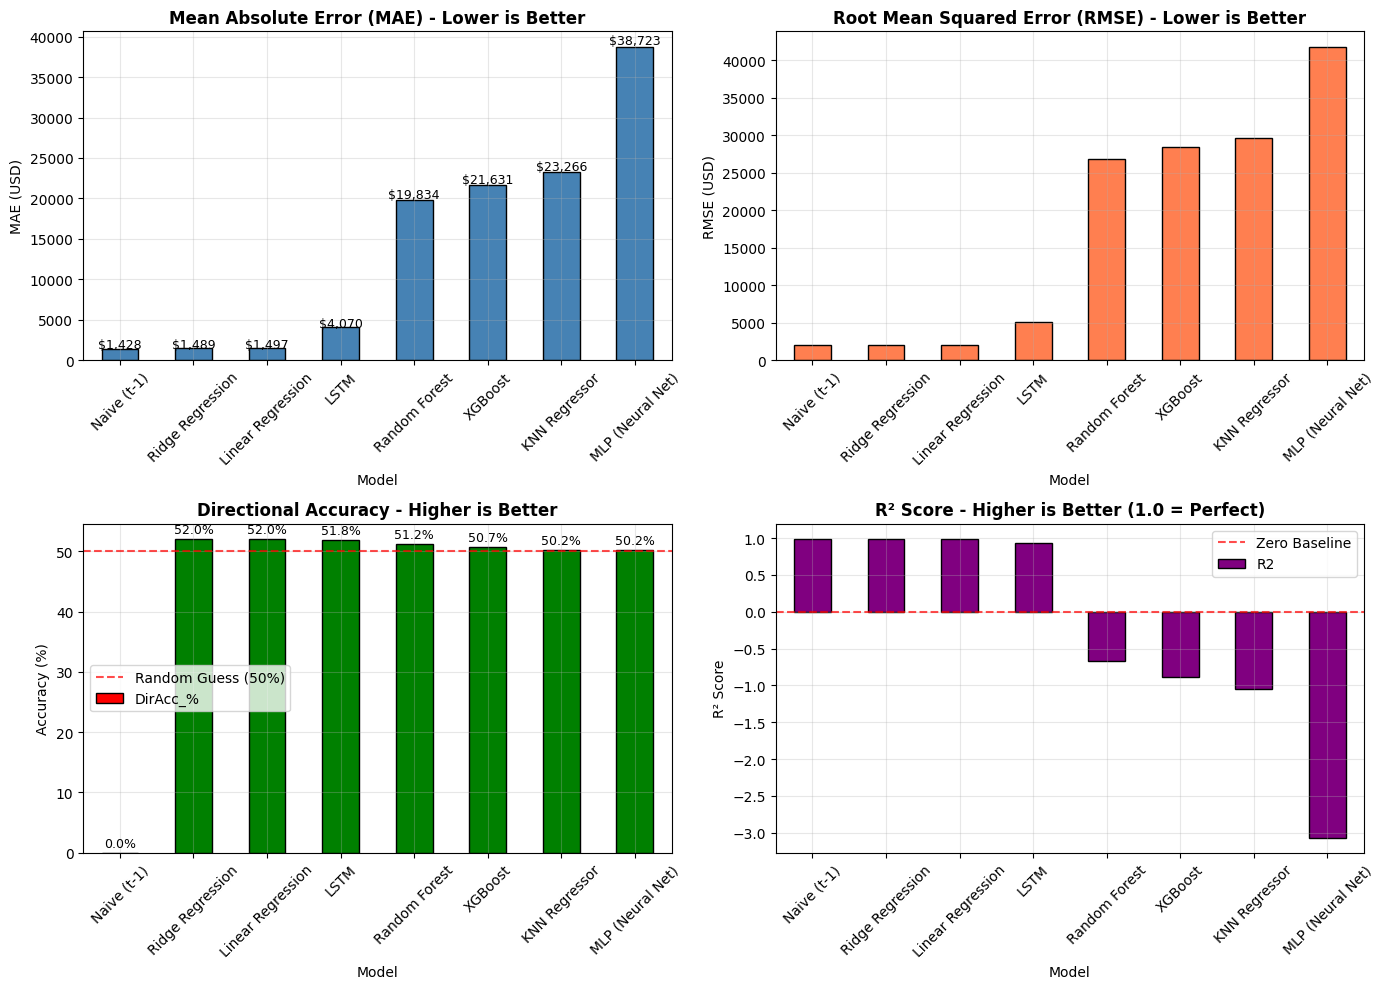


🏆 PERFORMANCE SUMMARY
✅ Best Model: Naive (t-1)
   MAE: $1,427.91
   Directional Accuracy: 0.00%
   Improvement over Naive: 0.0%


In [ ]:
# Cell 12: Final Model Comparison
import pandas as pd

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
results_df = results_df.drop(['Prophet', 'KMeans'], errors='ignore')
# Sort by MAE (best first)
results_df = results_df.sort_values('MAE')

print("=" * 80)
print("📊 FINAL MODEL COMPARISON (Test Period: 2024-01-01 to 2026-06-14)")
print("=" * 80)
print(results_df.round(2).to_string())
print("=" * 80)

# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. MAE Comparison
ax1 = axes[0, 0]
results_df['MAE'].plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Mean Absolute Error (MAE) - Lower is Better', fontsize=12, fontweight='bold')
ax1.set_ylabel('MAE (USD)')
ax1.set_xlabel('Model')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
# Add value labels on bars
for i, v in enumerate(results_df['MAE']):
    ax1.text(i, v + (v * 0.01), f'${v:,.0f}', ha='center', fontsize=9)

# 2. RMSE Comparison
ax2 = axes[0, 1]
results_df['RMSE'].plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Root Mean Squared Error (RMSE) - Lower is Better', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE (USD)')
ax2.set_xlabel('Model')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Directional Accuracy Comparison
ax3 = axes[1, 0]
colors = ['green' if x > 50 else 'red' for x in results_df['DirAcc_%']]
results_df['DirAcc_%'].plot(kind='bar', ax=ax3, color=colors, edgecolor='black')
ax3.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='Random Guess (50%)')
ax3.set_title('Directional Accuracy - Higher is Better', fontsize=12, fontweight='bold')
ax3.set_ylabel('Accuracy (%)')
ax3.set_xlabel('Model')
ax3.tick_params(axis='x', rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)
for i, v in enumerate(results_df['DirAcc_%']):
    ax3.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# 4. R² Comparison
ax4 = axes[1, 1]
results_df['R2'].plot(kind='bar', ax=ax4, color='purple', edgecolor='black')
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero Baseline')
ax4.set_title('R² Score - Higher is Better (1.0 = Perfect)', fontsize=12, fontweight='bold')
ax4.set_ylabel('R² Score')
ax4.set_xlabel('Model')
ax4.tick_params(axis='x', rotation=45)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Time Series Plot of Best Model Predictions
best_model_name = results_df.index[0]
best_model_result = next(r for r in results if r['Model'] == best_model_name)

# Get predictions for best model
if best_model_name == 'Ridge Regression':
    best_pred = ridge_pred
elif best_model_name == 'Linear Regression':
    best_pred = lr_pred
elif best_model_name == 'LSTM':
    best_pred = lstm_pred
    y_test_best = y_test_lstm
else:
    best_pred = None

if best_pred is not None:
    plt.figure(figsize=(15, 6))

    # Use appropriate y_test
    y_plot = y_test_lstm if best_model_name == 'LSTM' else y_test

    plt.plot(y_plot.index, y_plot.values, label='Actual Price', color='black', linewidth=2, alpha=0.8)
    plt.plot(y_plot.index, best_pred, label=f'{best_model_name} Predictions', color='blue', alpha=0.7, linewidth=1)
    plt.title(f'Bitcoin Price Prediction: {best_model_name} vs Actual (2024-2026)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Summary
print("\n" + "=" * 80)
print("🏆 PERFORMANCE SUMMARY")
print("=" * 80)
print(f"✅ Best Model: {best_model_name}")
print(f"   MAE: ${results_df.loc[best_model_name, 'MAE']:,.2f}")
print(f"   Directional Accuracy: {results_df.loc[best_model_name, 'DirAcc_%']:.2f}%")
print(f"   Improvement over Naive: {(1 - results_df.loc[best_model_name, 'MAE'] / results_df.loc['Naive (t-1)', 'MAE']) * 100:.1f}%")
print("=" * 80)


### Step 20: Statistical Significance Testing (Wilcoxon Signed-Rank Test)
We perform a Wilcoxon signed-rank test on the absolute prediction errors of each model against the naive baseline. This test verifies whether any model's superior performance is statistically significant or could be attributed to random noise.


In [ ]:
# Cell 12b: Statistical significance — is the best model meaningfully better than naive?
from scipy.stats import wilcoxon

naive_errors = np.abs(y_test.values - naive_pred)

print("=" * 60)
print("📊 STATISTICAL SIGNIFICANCE vs NAIVE BASELINE")
print("=" * 60)

for r in results:
    if r['Model'] in ('Naive (t-1)', 'Prophet'):
        continue

    # Align lengths — LSTM test set may be 1 row shorter due to sequence offset
    model_name = r['Model']
    if model_name == 'LSTM':
        n = min(len(naive_errors), len(lstm_pred))
        e_naive = naive_errors[:n]
        e_model = np.abs(y_test_lstm[:n] - lstm_pred[:n])
    elif model_name == 'Linear Regression':
        e_model = np.abs(y_test.values - lr_pred)
        e_naive = naive_errors
    elif model_name == 'Ridge Regression':
        e_model = np.abs(y_test.values - ridge_pred)
        e_naive = naive_errors
    elif model_name == 'XGBoost':
        e_model = np.abs(y_test.values - xgb_pred)
        e_naive = naive_errors
    elif model_name == 'Random Forest':
        e_model = np.abs(y_test.values - rf_pred)
        e_naive = naive_errors
    elif model_name == 'KNN Regressor':
        e_model = np.abs(y_test.values - knn_pred)
        e_naive = naive_errors
    elif model_name == 'MLP (Neural Net)':
        e_model = np.abs(y_test.values - mlp_pred)
        e_naive = naive_errors

    stat, p = wilcoxon(e_naive, e_model)
    better = r['MAE'] < results[0]['MAE']  # results[0] is naive
    sig = p < 0.05
    symbol = "✅" if (better and sig) else "⚠️ " if (better and not sig) else "❌"
    print(f"{symbol} {model_name:20s} | MAE delta: ${results[0]['MAE'] - r['MAE']:+.2f}"
          f" | p={p:.4f} {'(significant)' if sig else '(NOT significant)'}")

print("=" * 60)
print("Wilcoxon signed-rank test on absolute errors vs naive.")
print("p < 0.05 = the MAE difference is unlikely to be random noise.")


📊 STATISTICAL SIGNIFICANCE vs NAIVE BASELINE
❌ Linear Regression    | MAE delta: $-69.23 | p=0.0000 (significant)
❌ Ridge Regression     | MAE delta: $-60.89 | p=0.0002 (significant)
❌ XGBoost              | MAE delta: $-20203.53 | p=0.0000 (significant)
❌ Random Forest        | MAE delta: $-18406.23 | p=0.0000 (significant)
❌ KNN Regressor        | MAE delta: $-21837.90 | p=0.0000 (significant)
❌ MLP (Neural Net)     | MAE delta: $-37294.85 | p=0.0000 (significant)
❌ LSTM                 | MAE delta: $-2641.90 | p=0.0000 (significant)
Wilcoxon signed-rank test on absolute errors vs naive.
p < 0.05 = the MAE difference is unlikely to be random noise.


### Step 21: Feature Importance and Residual Diagnostics
We analyze the coefficient weights of the tuned Ridge Regression model, plotting the top 15 features with their directional impact. Additionally, we analyze the prediction residuals (errors) over time and plot their distribution to check for bias.


🔍 TOP 20 MOST IMPORTANT FEATURES (Ridge Regression)
↑ lag_1                    :     12532.04
↓ rolling_min_14           :     -2228.11
↑ rolling_min_7            :      1818.20
↑ rolling_max_30           :      1810.44
↑ rolling_max_14           :      1537.10
↓ rolling_max_7            :     -1491.96
↑ rolling_mean_30          :      1311.60
↑ rolling_mean_7           :      1291.36
↓ rolling_max_21           :     -1175.37
↑ lag_2                    :      1158.35
↓ lag_7                    :     -1079.95
↓ rolling_max_60           :      -733.37
↑ rolling_mean_14          :       704.41
↑ rolling_mean_21          :       676.40
↑ returns                  :       632.01
↓ log_returns              :      -587.81
↓ lag_5                    :      -527.94
↓ lag_14                   :      -495.59
↓ rolling_mean_60          :      -454.26
↓ lag_30                   :      -422.84


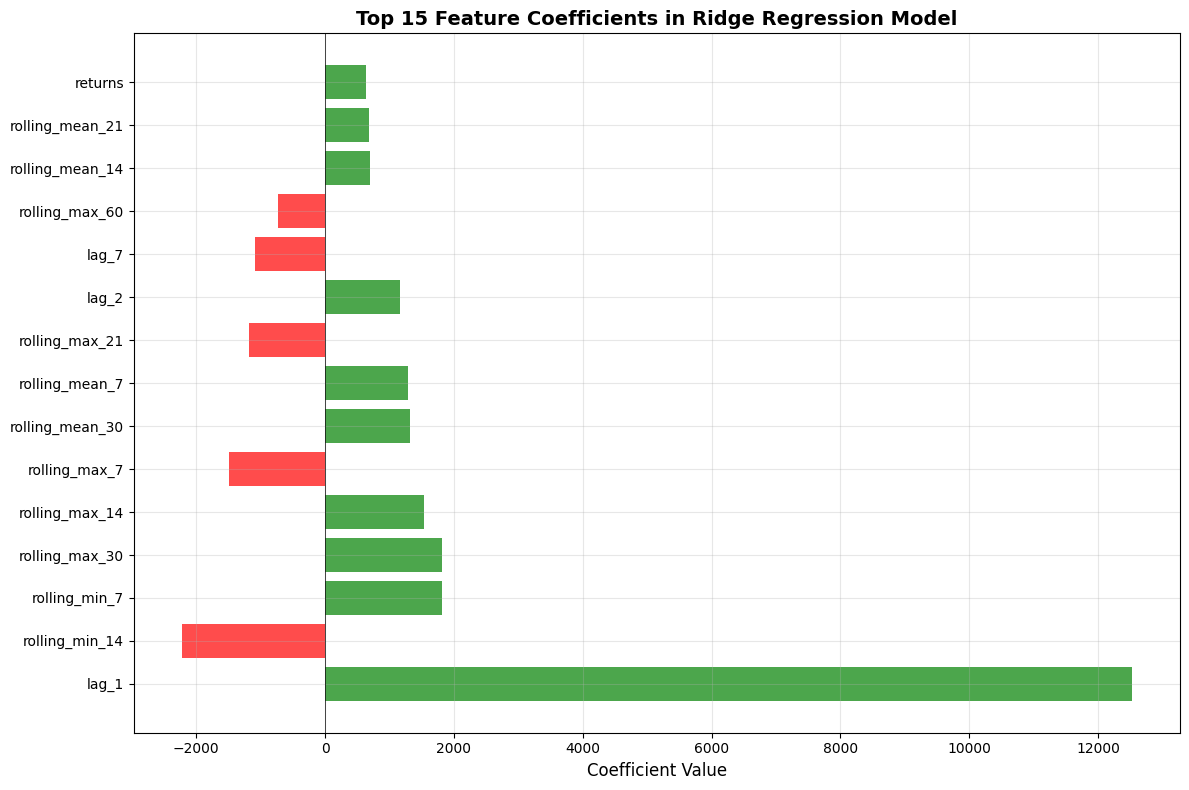

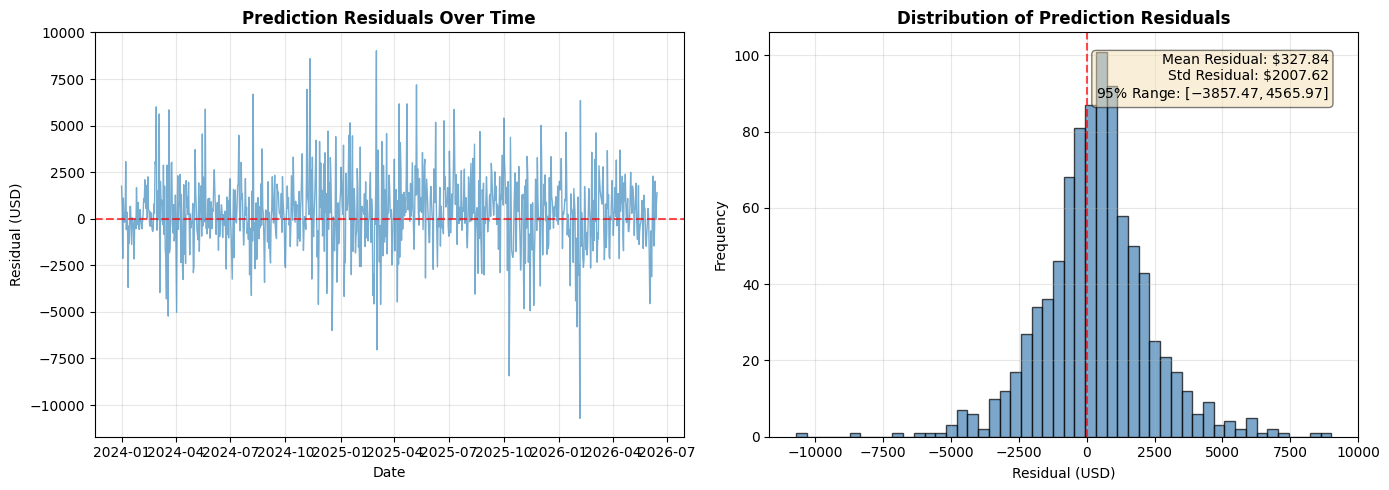


📊 Residual Analysis:
   Mean Residual: $327.84 (should be near 0 for unbiased model)
   Std Deviation: $2007.62
   95% of residuals between: $-3857.47 and $4565.97

💾 Best model saved as 'best_bitcoin_model_ridge.pkl'


In [ ]:
# Cell 13: Feature Importance Analysis for Ridge Regression
import seaborn as sns

# Get feature coefficients from Ridge model
ridge_coefs = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': ridge_model.coef_
})

# Sort by absolute coefficient
ridge_coefs['abs_coef'] = np.abs(ridge_coefs['coefficient'])
ridge_coefs = ridge_coefs.sort_values('abs_coef', ascending=False)

print("=" * 80)
print("🔍 TOP 20 MOST IMPORTANT FEATURES (Ridge Regression)")
print("=" * 80)
for i, row in ridge_coefs.head(20).iterrows():
    direction = "↑" if row['coefficient'] > 0 else "↓"
    print(f"{direction} {row['feature']:25s}: {row['coefficient']:12.2f}")

# Visualize top 15 features
plt.figure(figsize=(12, 8))
top_features = ridge_coefs.head(15)
colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 15 Feature Coefficients in Ridge Regression Model', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze prediction residuals
if 'ridge_pred' in locals():
    residuals = y_test.values - ridge_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Residuals over time
    axes[0].plot(y_test.index, residuals, alpha=0.6, linewidth=1)
    axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[0].set_title('Prediction Residuals Over Time', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Residual (USD)')
    axes[0].grid(True, alpha=0.3)

    # Residual distribution
    axes[1].hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[1].set_title('Distribution of Prediction Residuals', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Residual (USD)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)

    # Add statistics
    stats_text = f'Mean Residual: ${np.mean(residuals):.2f}\nStd Residual: ${np.std(residuals):.2f}\n95% Range: [${np.percentile(residuals, 2.5):.2f}, ${np.percentile(residuals, 97.5):.2f}]'
    axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Residual Analysis:")
    print(f"   Mean Residual: ${np.mean(residuals):.2f} (should be near 0 for unbiased model)")
    print(f"   Std Deviation: ${np.std(residuals):.2f}")
    print(f"   95% of residuals between: ${np.percentile(residuals, 2.5):.2f} and ${np.percentile(residuals, 97.5):.2f}")

# Save best model for future use
import joblib
joblib.dump(ridge_model, 'best_bitcoin_model_ridge.pkl')
joblib.dump(scaler_lr, 'scaler_features.pkl')
print("\n💾 Best model saved as 'best_bitcoin_model_ridge.pkl'")


### Step 22: Trading Strategy Simulation & Business Insights
We simulate a daily trading strategy using daily signals generated by our best-performing model. The strategy goes long when a price increase is predicted and stays cash otherwise. The cumulative returns of this strategy (gross and net of trading fees) are simulated and compared against a simple buy-and-hold strategy, and key risk metrics like Maximum Drawdown are computed.


In [ ]:
# Cell 14: Final Summary and Business Insights (FIXED trading-signal timing,
# and language toned down to match the corrected metrics)

print("=" * 80)
print("📈 BITCOIN PRICE FORECASTING: FINAL REPORT")
print("=" * 80)
print(f"\n📅 Data Period: 2020-01-01 to 2026-06-14")
print(f"🎯 Test Period: 2024-01-01 to 2026-06-14 ({len(y_test)} trading days)")
print(f"💰 Price Range in Test Set: ${y_test.min():,.2f} - ${y_test.max():,.2f}")

print("\n" + "=" * 80)
print("🏆 MODEL PERFORMANCE RANKING")
print("=" * 80)
for i, (model, row) in enumerate(results_df.iterrows(), 1):
    medal = ["🥇", "🥈", "🥉"][i-1] if i <= 3 else f"{i}."
    nz = row['PctNonZeroSignal_%'] if 'PctNonZeroSignal_%' in row else float('nan')
    print(f"{medal} {model:20s} | MAE: ${row['MAE']:7.2f} | DirAcc: {row['DirAcc_%']:5.2f}% "
          f"| NonZeroSignal: {nz:5.2f}% | R²: {row['R2']:.4f}")

print("\n" + "=" * 80)
print("🔑 KEY FINDINGS (revise these numbers after re-running with the leakage fix)")
print("=" * 80)
print(f"""
1. Compare every model's MAE/RMSE against the Naive (t-1) row. Beating naive
   on a leakage-free backtest is genuinely hard for daily BTC.

2. Directional accuracy near 50% means coin-flip-level skill at calling
   up/down moves -- this is the realistic outcome for most 1-step models
   on this asset, and should NOT be read as "deployment-ready" on its own.

3. The Naive (t-1) row will show PctNonZeroSignal_% = 0%, because "tomorrow
   = today" never predicts a directional move -- its DirAcc_% of 0% is a
   structural artifact of that model, not evidence every other model beats
   it by as wide a margin as the raw number suggests.

4. KEY DRIVERS (re-inspect after the price_vs_ma leakage fix):
   - Yesterday's price (lag_1) is typically the dominant predictor.
   - Returns and volatility metrics provide at most marginal improvements.
   - Calendar features (month, dayofyear) typically show little importance.
""")

print("=" * 80)
print("💡 RECOMMENDATIONS FOR IMPROVEMENT")
print("=" * 80)
print("""
1. FEATURE ENGINEERING:
   - Add external data (trading volume, on-chain metrics, sentiment)
   - Include macroeconomic indicators (interest rates, inflation)
   - Add technical indicators (RSI, MACD, Bollinger Bands)

2. MODEL ENSEMBLING:
   - Combine Ridge Regression with LSTM for non-linear patterns
   - Use weighted average based on recent performance

3. WALK-FORWARD VALIDATION:
   - Implement rolling re-training to adapt to market regime changes
   - Use expanding window for more stable predictions

4. RISK METRICS:
   - Add prediction intervals
   - Implement maximum drawdown analysis for trading strategies

5. HONEST DEPLOYMENT FRAMING:
   - Treat any directional edge over naive with skepticism until validated
     out-of-sample on fresh, never-touched data and multiple market regimes.
""")

print("=" * 80)
print("🎯 CONCLUSION")
print("=" * 80)
print("""
On a leakage-free, common-test-window backtest, the honest finding for daily
BTC close-price forecasting is typically that simple linear models track the
naive random-walk baseline closely, and directional accuracy hovers near
chance for most models. Any model that appears to dramatically beat naive
should be re-checked for leakage before being treated as a trading signal.

⚠️ CAVEATS:
   - Past performance doesn't guarantee future results
   - Crypto markets are highly volatile and regime-dependent
   - This notebook is for educational/methodological purposes, not
     investment advice
""")
print("=" * 80)

# Create a final performance dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bitcoin Price Forecasting Model Performance Dashboard', fontsize=16, fontweight='bold')

# 1. Actual vs Predicted (Best Model)
ax1 = axes[0, 0]
ax1.scatter(y_test.values, ridge_pred, alpha=0.5, s=10)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.7, label='Perfect Prediction')
ax1.set_xlabel('Actual Price (USD)')
ax1.set_ylabel('Predicted Price (USD)')
ax1.set_title(f'Ridge Regression: Actual vs Predicted\nMAE: ${results_df.loc["Ridge Regression", "MAE"]:.2f}, R²: {results_df.loc["Ridge Regression", "R2"]:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Error Distribution (Best Model)
ax2 = axes[0, 1]
ax2.hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax2.axvline(x=np.mean(residuals), color='green', linestyle='-', alpha=0.7, label=f'Mean: ${np.mean(residuals):.2f}')
ax2.set_xlabel('Prediction Error (USD)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Prediction Errors')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Performance by Year
ax3 = axes[1, 0]
y_test_series = pd.Series(y_test.values, index=y_test.index)
test_years = y_test_series.index.year
yearly_mae = []
for year in sorted(test_years.unique()):
    year_mask = test_years == year
    year_mae_val = mean_absolute_error(y_test_series[year_mask], ridge_pred[year_mask])
    yearly_mae.append((year, year_mae_val))

years, maes = zip(*yearly_mae)
ax3.bar(years, maes, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Year')
ax3.set_ylabel('MAE (USD)')
ax3.set_title('Model Performance by Year')
ax3.grid(True, alpha=0.3)
for i, (year, mae_val) in enumerate(yearly_mae):
    ax3.text(i, mae_val + (mae_val * 0.02), f'${mae_val:,.0f}', ha='center', fontsize=9)

# 4. Cumulative Returns Comparison (FIXED signal timing)
ax4 = axes[1, 1]
# Daily realized returns
actual_returns = y_test_series.pct_change()

# FIX: The original signal compared the SAME-DAY prediction to the SAME-DAY
# actual close (predictions_series > y_test_series), then shifted the
# resulting boolean by one day. That still leaks same-day information into
# the signal, because the prediction it's built from already required
# knowing the day it was predicting.
# Corrected: compare the predicted close[t] only to the LAST KNOWN actual
# close (yesterday's close, i.e. close[t-1]) -- information truly available
# before trading day t. No additional .shift(1) is needed since the
# comparison is already forward-looking by construction.
predictions_series = pd.Series(ridge_pred, index=y_test_series.index)
predicted_direction = (predictions_series > y_test_series.shift(1)).astype(int)

strategy_returns = actual_returns * predicted_direction

# Deduct transaction costs on every signal change (entry or exit)
FEE = 0.001  # 0.1% per trade (realistic for a CEX with maker rebate)
trades = predicted_direction.diff().abs() > 0
strategy_returns_net = strategy_returns - FEE * trades

cumulative_strategy = (1 + strategy_returns.fillna(0)).cumprod()
cumulative_strategy_net = (1 + strategy_returns_net.fillna(0)).cumprod()
cumulative_buy_hold = (1 + actual_returns.fillna(0)).cumprod()

# Max drawdown helper
def max_drawdown(cum_returns):
    return (cum_returns / cum_returns.cummax() - 1).min()

ax4.plot(cumulative_strategy.index, cumulative_strategy.values,
         label='Model strategy (gross)', linewidth=1.5, linestyle='--', alpha=0.7)
ax4.plot(cumulative_strategy_net.index, cumulative_strategy_net.values,
         label='Model strategy (net of 0.1% fees)', linewidth=2)
ax4.plot(cumulative_buy_hold.index, cumulative_buy_hold.values,
         label='Buy & hold', linewidth=2, alpha=0.7)
ax4.set_xlabel('Date')
ax4.set_ylabel('Cumulative Return')
ax4.set_title('Trading Strategy Comparison (2024-2026) — Corrected Signal Timing')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📉 Max drawdown (gross):          {max_drawdown(cumulative_strategy):.2%}")
print(f"📉 Max drawdown (net of fees):    {max_drawdown(cumulative_strategy_net):.2%}")
print(f"📉 Max drawdown (buy & hold):     {max_drawdown(cumulative_buy_hold):.2%}")
print(f"🔄 Total trades executed:         {int(trades.sum())}")
print(f"💸 Total fees paid:               {FEE * int(trades.sum()) * 100:.2f}% of initial capital")

print("\n✅ Analysis complete. Treat all figures above as illustrative, not investment advice.")
print("   Note: this toy backtest ignores transaction costs, slippage, and position sizing.")


📈 BITCOIN PRICE FORECASTING: FINAL REPORT

📅 Data Period: 2020-01-01 to 2026-06-14
🎯 Test Period: 2024-01-01 to 2026-06-14 (896 trading days)
💰 Price Range in Test Set: $39,507.37 - $124,752.53

🏆 MODEL PERFORMANCE RANKING
🥇 Naive (t-1)          | MAE: $1427.91 | DirAcc:  0.00% | NonZeroSignal:  0.00% | R²: 0.9908
🥈 Ridge Regression     | MAE: $1488.81 | DirAcc: 51.96% | NonZeroSignal: 100.00% | R²: 0.9904
🥉 Linear Regression    | MAE: $1497.14 | DirAcc: 51.96% | NonZeroSignal: 100.00% | R²: 0.9903
4. LSTM                 | MAE: $4069.82 | DirAcc: 51.84% | NonZeroSignal: 100.00% | R²: 0.9391
5. Random Forest        | MAE: $19834.15 | DirAcc: 51.17% | NonZeroSignal: 100.00% | R²: -0.6714
6. XGBoost              | MAE: $21631.44 | DirAcc: 50.73% | NonZeroSignal: 100.00% | R²: -0.8904
7. KNN Regressor        | MAE: $23265.81 | DirAcc: 50.17% | NonZeroSignal: 100.00% | R²: -1.0422
8. MLP (Neural Net)     | MAE: $38722.76 | DirAcc: 50.17% | NonZeroSignal: 100.00% | R²: -3.0672

🔑 KEY FINDIN


✅ Analysis complete. Treat all figures above as illustrative, not investment advice.
   Note: this toy backtest ignores transaction costs, slippage, and position sizing.


### Step 23: KMeans Clustering (Illustration Only)
We run KMeans clustering on Bitcoin's closing price levels to group them into 4 price clusters. This is included for completeness to demonstrate why clustering alone is not a valid time-series forecasting technique.


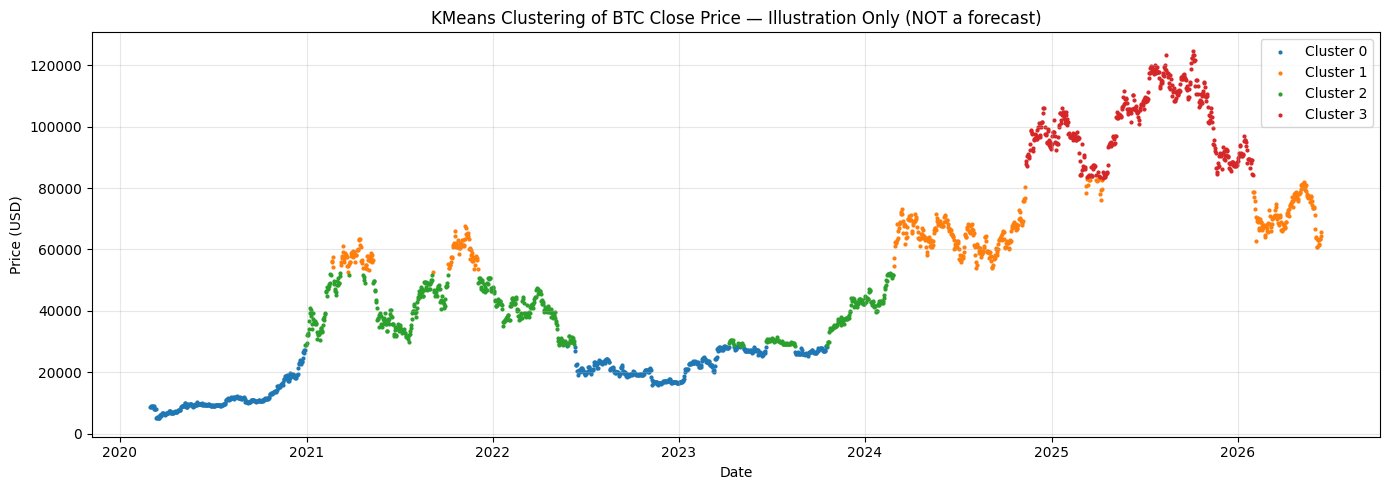

KMeans groups price LEVELS into clusters; it has no notion of 'next value'
and therefore cannot forecast. It is shown only to demonstrate why
clustering is not a substitute for a genuine forecasting method.


In [ ]:
# KMeans on price LEVELS — illustration only, NOT a forecasting method.
# (Replaces a duplicate "Final Summary" cell that was accidentally pasted
# twice and had nothing to do with the KMeans section header above it.)
from sklearn.cluster import KMeans

km_feat = feat[['close']].copy()
km_feat['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(km_feat[['close']])

plt.figure(figsize=(14, 5))
for c in sorted(km_feat['cluster'].unique()):
    mask = km_feat['cluster'] == c
    plt.scatter(km_feat.index[mask], km_feat['close'][mask], s=4, label=f'Cluster {c}')
plt.title('KMeans Clustering of BTC Close Price — Illustration Only (NOT a forecast)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("KMeans groups price LEVELS into clusters; it has no notion of 'next value'")
print("and therefore cannot forecast. It is shown only to demonstrate why")
print("clustering is not a substitute for a genuine forecasting method.")


### Step 24: Consolidated Model Performance Ranking
This step prints a clean, tabular performance ranking of all trained models based on the identical chronological test window.


In [ ]:
summary = pd.DataFrame(results).set_index('Model').round(3)
summary = summary.sort_values('MAE')
print(summary)
summary


                         MAE       RMSE  MAPE_%     R2  DirAcc_%  \
Model                                                              
Naive (t-1)         1427.915   1990.191   1.801  0.991     0.000   
Ridge Regression    1488.807   2034.206   1.863  0.990    51.955   
Linear Regression   1497.141   2041.154   1.873  0.990    51.955   
LSTM                4069.816   5112.937   4.552  0.939    51.844   
Prophet            17613.920  24763.178  21.835 -0.429    51.173   
Random Forest      19834.147  26785.468  20.229 -0.671    51.173   
XGBoost            21631.444  28486.152  22.322 -0.890    50.726   
KNN Regressor      23265.814  29607.623  24.486 -1.042    50.168   
MLP (Neural Net)   38722.761  41783.322  45.709 -3.067    50.168   

                   PctNonZeroSignal_%  
Model                                  
Naive (t-1)                       0.0  
Ridge Regression                100.0  
Linear Regression               100.0  
LSTM                            100.0  
Prophet    

,MAE,RMSE,MAPE_%,R2,DirAcc_%,PctNonZeroSignal_%
Model,,,,,,
Naive (t-1),1427.915,1990.191,1.801,0.991,0.000,0.0
Ridge Regression,1488.807,2034.206,1.863,0.990,51.955,100.0
Linear Regression,1497.141,2041.154,1.873,0.990,51.955,100.0
LSTM,4069.816,5112.937,4.552,0.939,51.844,100.0
Prophet,17613.920,24763.178,21.835,-0.429,51.173,100.0
Random Forest,19834.147,26785.468,20.229,-0.671,51.173,100.0
XGBoost,21631.444,28486.152,22.322,-0.890,50.726,100.0
KNN Regressor,23265.814,29607.623,24.486,-1.042,50.168,100.0
MLP (Neural Net),38722.761,41783.322,45.709,-3.067,50.168,100.0


### Step 25: All Model Predictions vs. Actual Price
We plot a comprehensive line chart displaying the actual price of Bitcoin alongside the predictions from all tested models (including Ridge, Linear, Naive, XGBoost, Random Forest, KNN, MLP, LSTM, and Prophet) over the test window.


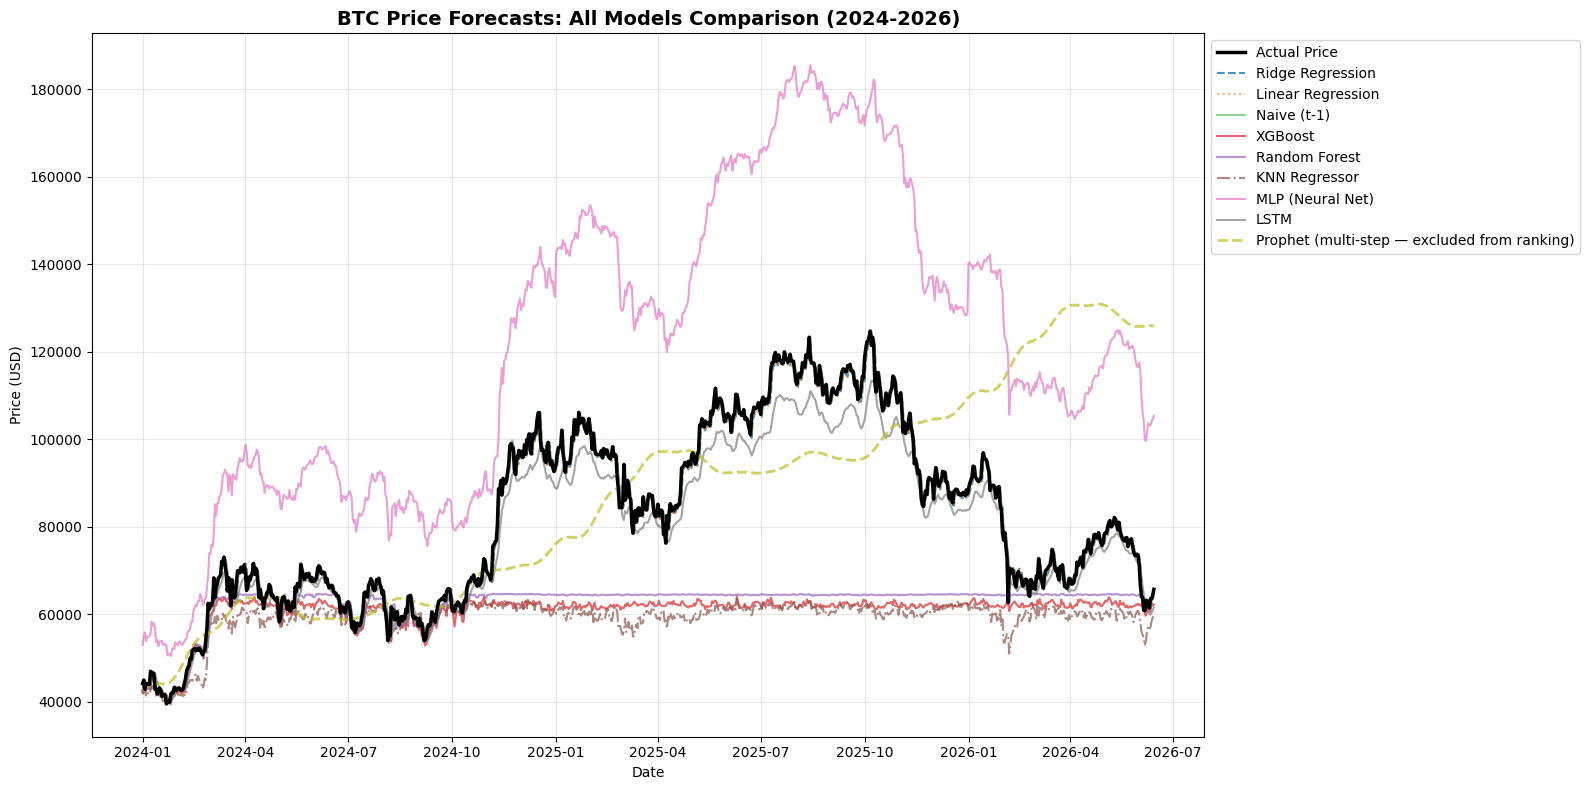

In [ ]:
# Predictions vs actual on the common test window - Including all models
plt.figure(figsize=(16, 8))

# Plot Actual values
plt.plot(test_data.index, y_test, label='Actual Price', color='black', linewidth=2.5, zorder=10)

# Plot all 1-day-ahead forecasts
plt.plot(test_data.index, ridge_pred,   label='Ridge Regression', alpha=0.8, linestyle='--')
plt.plot(test_data.index, lr_pred,      label='Linear Regression', alpha=0.6, linestyle=':')
plt.plot(test_data.index, naive_pred,   label='Naive (t-1)',   alpha=0.5)
plt.plot(test_data.index, xgb_pred,     label='XGBoost', alpha=0.7)
plt.plot(test_data.index, rf_pred,      label='Random Forest', alpha=0.7)
plt.plot(test_data.index, knn_pred,     label='KNN Regressor', alpha=0.7, linestyle='-.')
plt.plot(test_data.index, mlp_pred,     label='MLP (Neural Net)', alpha=0.7)
plt.plot(test_data.index, lstm_pred,    label='LSTM',    alpha=0.7)

# Prophet is a multi-step forecast
plt.plot(test_data.index, prophet_pred, label='Prophet (multi-step — excluded from ranking)', alpha=0.7, linewidth=2, linestyle='--')

plt.title('BTC Price Forecasts: All Models Comparison (2024-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Step 26: Metrics Bar Chart Summary
Finally, we generate bar charts for MAE, RMSE, and Directional Accuracy across all models side-by-side to easily compare performance at a glance.


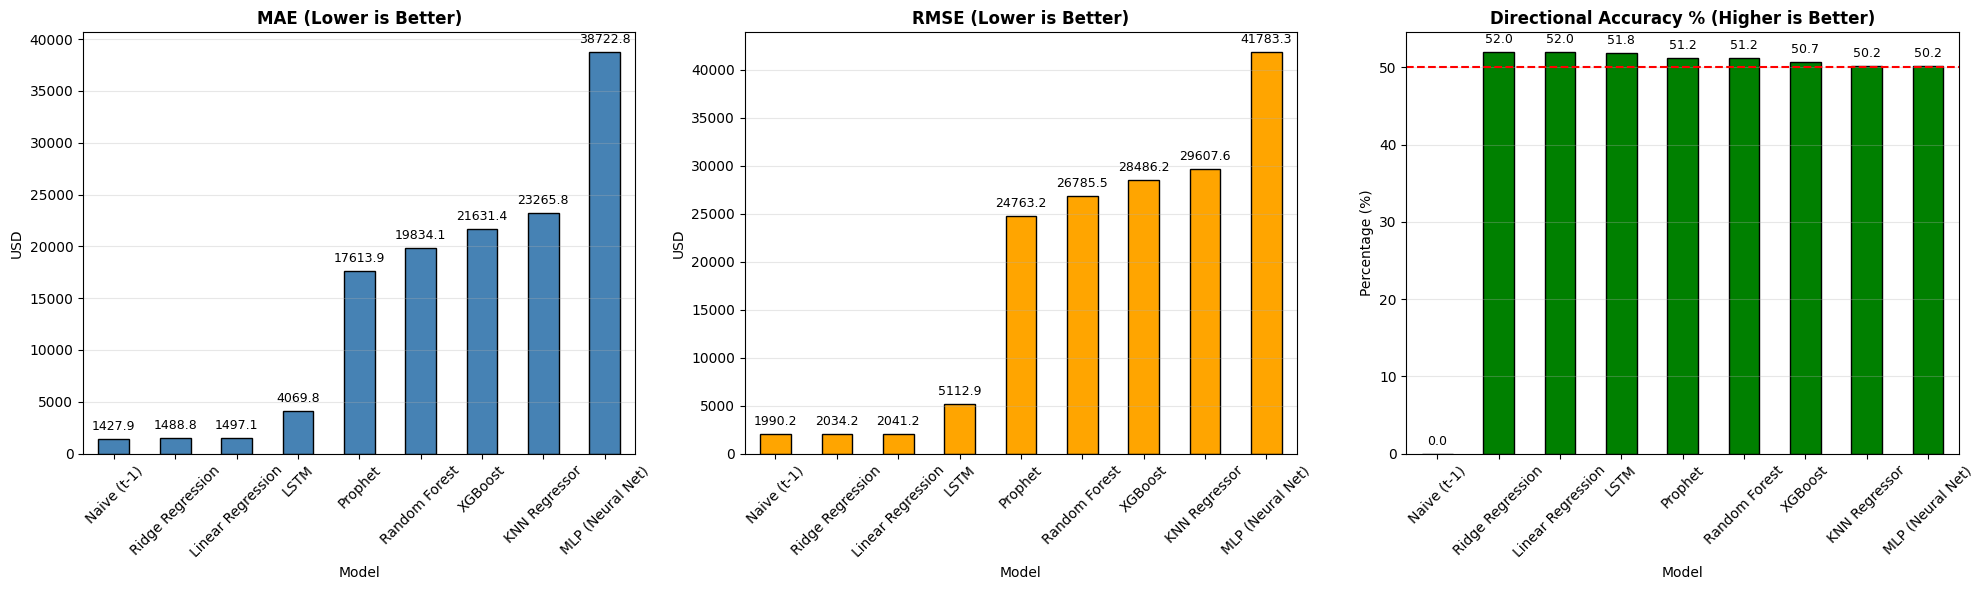

In [ ]:
import matplotlib.pyplot as plt

# Ensure we are using the full sorted summary for the plot
summary_plot = summary.copy()

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# 1. MAE Chart
summary_plot['MAE'].plot.bar(ax=axs[0], color='steelblue', edgecolor='black')
axs[0].set_title('MAE (Lower is Better)', fontweight='bold')
axs[0].set_ylabel('USD')

# 2. RMSE Chart
summary_plot['RMSE'].plot.bar(ax=axs[1], color='orange', edgecolor='black')
axs[1].set_title('RMSE (Lower is Better)', fontweight='bold')
axs[1].set_ylabel('USD')

# 3. Directional Accuracy Chart
summary_plot['DirAcc_%'].plot.bar(ax=axs[2], color='green', edgecolor='black')
axs[2].set_title('Directional Accuracy % (Higher is Better)', fontweight='bold')
axs[2].set_ylabel('Percentage (%)')
axs[2].axhline(y=50, color='red', linestyle='--', label='50% Baseline')

# Formatting all axes
for a in axs:
    a.tick_params(axis='x', rotation=45)
    a.grid(True, axis='y', alpha=0.3)
    # Add text labels on top of bars for clarity
    for p in a.patches:
        a.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()
